# 04. Quench dynamics & state preparation

01r Rydberg quench / 制备 across backends。四个 Part 各自自包含(各自有 imports 和 segment-shim)。

- **Part A — 4×4 quench benchmark**:Δ-sweep quench,exact / MPS / GPUTN / PEPS 对照 + 独立 10×10 PEPS。
- **Part B — |+⟩ quench benchmark**:finite 3×3,5 backends + per-string phase + pepskit bulk 参考。
- **Part C — Plus-state preparation**:制备协议 + sublattice-X echo + 制备后 Ising 演化。
- **Part D — PEPSKit iPEPS quench**:infinite-PEPS bulk(thermodynamic-limit)参考 + d=3 hyperfine Rabi sanity。

合并自 `run_quench_benchmark` + `01r_plus_quench_benchmark` + `plus_state_preparation` + `01r_pepskit_quench`。

## Part A — 4×4 Rydberg quench benchmark(exact / MPS / GPUTN / PEPS + 10×10)

同一套 4×4 `1r` 方格 + 同一条失谐扫描 protocol。`1r` 每格两能级 `|1>`(基态)/ `|r>`(Rydberg),最近邻 VdW:

$$
H(t) = \sum_{i=0}^{15}\left[\frac{\Omega(t)}{2}\,\sigma^x_i - \Delta_i(t)\,n^r_i\right] + \sum_{\langle i,j\rangle} V_{ij}\,n^r_i n^r_j
$$

其中 $\sigma^x_i=|r\rangle\langle 1|_i+|1\rangle\langle r|_i$,$n^r_i=|r\rangle\langle r|_i$,$\Delta_i(t)=\Delta(t)+\Delta_{\mathrm{addr},i}(t)$,$V_{ij}=C_6/r_{ij}^6$(`mode="nn"` 只取最近邻)。$C_6=2\pi\times874\ \mathrm{GHz\cdot\mu m^6}$,故 $r=6\,\mu m$ 时 $V\approx2\pi\times18\ \mathrm{MHz}$,$r=10\,\mu m$ 时 $V\approx2\pi\times0.874\ \mathrm{MHz}$。角频率均为 rad/s。

后端:`exact` 基准,`mps`(TeNPy CPU)、`peps`(YASTN finite,二维主路径)、`gputn`(cuTensorNet/CuPy,experimental)。

In [1]:
# Pin BLAS/OpenMP to 1 thread BEFORE importing numpy/scipy/tenpy.
# Small TN tensors (DMRG/TDVP/PEPS) => multi-threaded BLAS oversubscribes
# cores and runs 10-40x SLOWER on a loaded box. This cell must stay first
# and run before any import: the libraries read these variables only once,
# at import time.
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(_v, "1")
print("BLAS/OpenMP threads pinned to", os.environ.get("OMP_NUM_THREADS"))

BLAS/OpenMP threads pinned to 1


In [2]:
import time

import numpy as np
import matplotlib.pyplot as plt
import ryd_gate as rg
from ryd_gate import InteractionSpec
from ryd_gate.lattice import Register

两条平滑波形,先升 Rabi/detuning 再降。

**Sweep 时间上界(decay)**:300 K 下 70S Rydberg decay $\Gamma=1/151.55\ \mu s^{-1}$。要单原子存活率 $>0.99$(loss $<1\%$),需 $e^{-\Gamma t}>0.99 \Rightarrow t\lesssim -\ln(0.99)\times151.55\ \mu s\approx 1.52\ \mu s$,故 sweep 不能太久(本 notebook 取 1.5 μs)。

- **Rabi** smooth flat-top:smootherstep $h(u)=10u^3-15u^4+6u^5$ 平滑开、保持平台、再平滑关;平台边缘宽 $\tau_r=0.09T$。两次共振穿越附近 $\Omega/2$ 已在平台上,avoided-crossing gap 足够大,扫回时更易把多体态带回基态。
- **Detuning** 余弦往返:$\Delta(t)=\Delta_{\rm mid}-\Delta_{\rm amp}\cos(2\pi t/T)$,$\Delta_{\rm mid}=(\Delta_{\rm start}+\Delta_{\rm end})/2$、$\Delta_{\rm amp}=(\Delta_{\rm end}-\Delta_{\rm start})/2$,取值 $-10\to+10\to-10$ MHz、端点斜率为零。

实现提示:detuning 由 chirp AOM RF / EOM-PLL / 直接调激光频率给出,AWG 输出连续相位 $\phi(t)=2\pi\int f_{\rm RF}(t)\,dt$。AOM 调 Rabi 光强时链路 $V_{\rm AWG}\to P_{\rm RF}\to P_{\rm opt}\to\Omega$,欲 $\Omega\propto b(t)$ 通常需 $P_{\rm opt}\propto b(t)^2$;故 `omega_half_t` 是目标 Rabi envelope,实际 AWG 电压按测得的 AOM transfer function 反推。

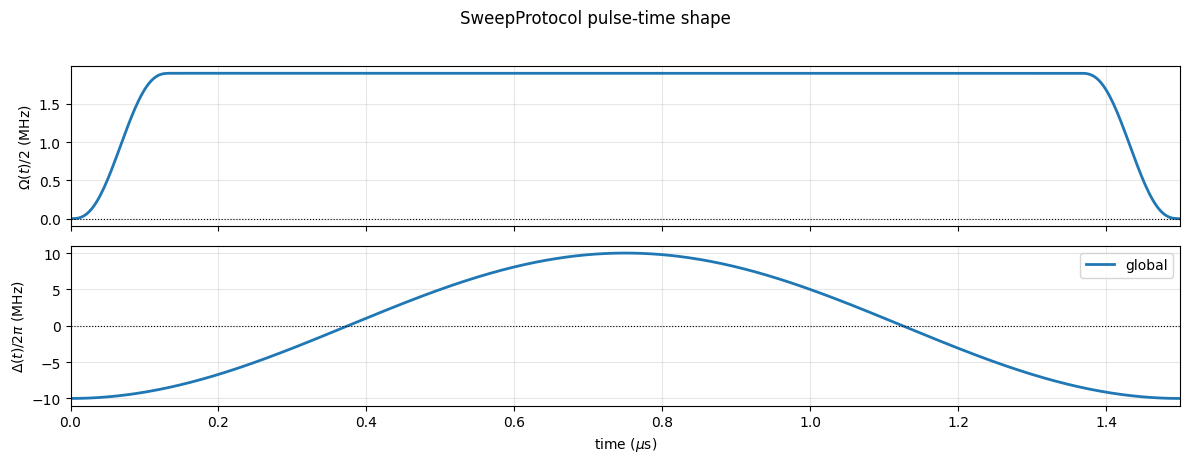

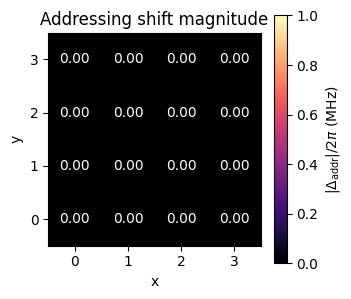

In [3]:
# No local-addressing detuning shift for this run.
Lx = 4
Ly = 4
N_sites = Lx * Ly

# Experimental-style parameters
a_um = 5                         # lattice spacing, um
C6_70s = 2 * np.pi * 874e9         # rad/s * um^6, Rb 70S typical

local_detuning_offsets = np.zeros(N_sites)
# 1. 几何 + 能级结构：4x4 方格，每个格点是 |1>(基态) / |r>(Rydberg) 两能级
geom = Register.rectangle(Lx, Ly, spacing_um=a_um)


Omega = 2 * np.pi * 3.8e6          # rad/s
delta_start = -2 * np.pi * 10.0e6   # rad/s
delta_end = 2 * np.pi * 10.0e6      # rad/s
t_sweep = 1.5e-6                   # s
omega_ramp_frac = 0.1

# Effectively global Rabi
def omega_half_t(t):
    ramp_frac = 0.09
    s = np.clip(t / max(t_sweep, np.finfo(float).eps), 0.0, 1.0)

    def smoothstep5(u):
        u = np.clip(u, 0.0, 1.0)
        return 10.0 * u**3 - 15.0 * u**4 + 6.0 * u**5

    if s < ramp_frac:
        env = smoothstep5(s / ramp_frac)
    elif s > 1.0 - ramp_frac:
        env = smoothstep5((1.0 - s) / ramp_frac)
    else:
        env = 1.0

    return 0.5 * Omega * env

# 全局 Rydberg 失谐：平滑往返扫频 -10 MHz -> +10 MHz -> -10 MHz
def delta_t(t):
    s = np.clip(t / max(t_sweep, np.finfo(float).eps), 0.0, 1.0)
    delta_mid = 0.5 * (delta_start + delta_end)
    delta_amp = 0.5 * (delta_end - delta_start)
    return delta_mid - delta_amp * np.cos(2.0 * np.pi * s)

# 局部 addressing shift；这里全部为 0
def delta_local(t, ind):
    return local_detuning_offsets[ind]

# 2. 自定义 sweep：global Delta(t) 和 local address shift 分开输入
protocol = rg.SweepProtocol(
    t_gate=t_sweep,
    omega_half_fn=omega_half_t,
    delta_fn=delta_t,
    address_fn=delta_local,
    n_steps=120,
)
system = rg.RydbergSystem.from_lattice(
    geom, "1r",
    interaction=InteractionSpec(C6=C6_70s, mode="nn"),       # 近邻 VdW；TN 勿用默认 all
    protocol=protocol,
)
params = system.unpack_params([])
t_eval = np.linspace(0.0, t_sweep, 7)

protocol.plot(system=system, params=params, savefig=False)

# 设置 TN 时间步长
dt_tn = 0.2 / Omega  # seconds; 0.2 * Omega^{-1}, same time unit as t_sweep/t_eval


## 3. Exact state-vector baseline

`backend="exact"`:每个 `t_eval` 保存态矢量,每段对完整 $H$ 做精确矩阵指数(无 Trotter 误差,仅段内 $H$ 常数化的离散误差)。平均/逐格点 Rydberg occupation 由 `system.expectation(...)` 读出——所有近似后端的数值基准。

In [4]:
# 3a. 精确后端：states 是态矢量，用 system.expectation 读 Rydberg 均值和逐格点 occupation。
method = "exact"
_t0 = time.perf_counter()
res = rg.simulate(system, [], "all_ground", backend="exact", t_eval=t_eval)
exact_elapsed = time.perf_counter() - _t0

exact_n_mean = np.asarray([
    system.expectation("sum_nr", psi) / system.N
    for psi in res.states
])
exact_n_i = np.asarray([
    [system.expectation(f"n_r_{i}", psi) for i in range(system.N)]
    for psi in res.states
])

print(f"Exact elapsed: {exact_elapsed:.3f} s")
print("time(us)  exact <n_r>")
for t, exact_val in zip(res.times * 1e6, exact_n_mean):
    print(f"{t:7.3f}   {exact_val:10.4f}")


Exact elapsed: 336.901 s
time(us)  exact <n_r>
  0.000       0.0000
  0.250       0.0507
  0.500       0.4132
  0.750       0.4200
  1.000       0.3801
  1.250       0.1689
  1.500       0.0958


### 逐格点 occupation color map

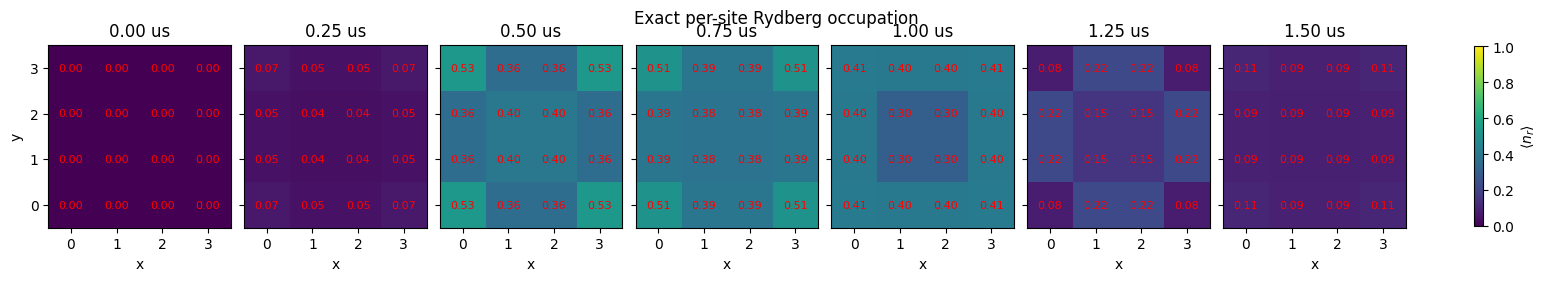

In [5]:
# 3b. 每个时刻的 4x4 Rydberg occupation color map：使用当前算法的逐格点 <n_r_i>。
if exact_n_i is None:
    print("exact has no successful data to plot.")
else:
    fig_h, axes_h = plt.subplots(1, len(t_eval), figsize=(2.2 * len(t_eval), 2.5), constrained_layout=True)
    axes_h = np.atleast_1d(axes_h)

    for ax_h, t, occ in zip(axes_h, res.times, exact_n_i):
        grid = occ.reshape(Lx, Ly)
        im = ax_h.imshow(grid.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
        ax_h.set_title(f"{t * 1e6:.2f} us")
        ax_h.set_xticks(range(Lx))
        ax_h.set_yticks(range(Ly))
        ax_h.set_xlabel("x")
        if ax_h is axes_h[0]:
            ax_h.set_ylabel("y")
        else:
            ax_h.set_yticklabels([])
        for ix in range(Lx):
            for iy in range(Ly):
                val = grid[ix, iy]
                txt_color = "red"
                ax_h.text(ix, iy, f"{val:.2f}", ha="center", va="center", color=txt_color, fontsize=8)

    fig_h.colorbar(im, ax=axes_h, shrink=0.82, label=r"$\langle n_r \rangle$")
    fig_h.suptitle("Exact per-site Rydberg occupation", y=1.05)
    plt.show()


## 4. TeNPy CPU MPS-TDVP (`mps`)

把 4×4 按 snake ordering 拉成一维 MPS、用 TeNPy TDVP 演化。关键参数 `chi_max`、`dt`;interaction 沿用 `system` 的最近邻 pair list。

In [6]:
# 4a. TeNPy MPS-TDVP (`backend="mps"`)：TN 后端把 <n_r> 和每个格点 <n_i> 记录在 metadata["obs"] 里。
method = "mps"
# 开始计时
_t0 = time.perf_counter()
#开始模拟
res_tenpy = rg.simulate(
    system, [], "all_ground",
    backend="mps", t_eval=t_eval, observables=["n_mean", "n_i"],
    backend_options={"chi_max": 32, "dt": dt_tn, "svd_min": 1e-10},
)
# 计时结束
tenpy_elapsed = time.perf_counter() - _t0
# 读取结果
tenpy_n_mean = np.asarray(res_tenpy.metadata["obs"]["n_mean"])
tenpy_n_i = np.asarray(res_tenpy.metadata["obs"]["n_i"])
# 计算误差
tenpy_diff_mean = float(np.max(np.abs(tenpy_n_mean - exact_n_mean))) if "exact_n_mean" in globals() else np.nan
tenpy_diff_i = float(np.max(np.abs(tenpy_n_i - exact_n_i))) if "exact_n_i" in globals() else np.nan

print(f"TeNPy elapsed: {tenpy_elapsed:.3f} s")
print("time(us)  exact <n_r>  TeNPy <n_r>")
for t, exact_val, tn_val in zip(t_eval * 1e6, exact_n_mean, tenpy_n_mean):
    print(f"{t:7.3f}   {exact_val:10.4f}  {tn_val:10.4f}")
print(f"max |delta <n_r>| = {tenpy_diff_mean:.3e}; max |delta <n_i>| = {tenpy_diff_i:.3e}")



/home/chance/Ryd-gate-modeling/.venv/lib/python3.10/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


TeNPy elapsed: 286.134 s
time(us)  exact <n_r>  TeNPy <n_r>
  0.000       0.0000      0.0000
  0.250       0.1081      0.1084
  0.500       0.8432      0.8429
  0.750       0.9609      0.9610
  1.000       0.8285      0.8287
  1.250       0.1152      0.1152
  1.500       0.0024      0.0024
max |delta <n_r>| = 2.416e-04; max |delta <n_i>| = 4.966e-04


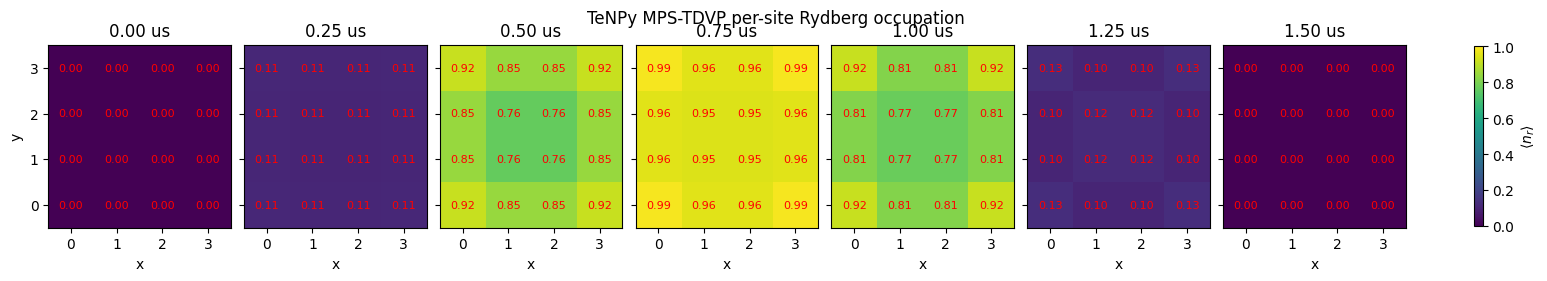

In [7]:
# 4b. 每个时刻的 4x4 Rydberg occupation color map：使用当前算法的逐格点 <n_r_i>。
if tenpy_n_i is None:
    print("mps has no successful data to plot.")
else:
    fig_h, axes_h = plt.subplots(1, len(t_eval), figsize=(2.2 * len(t_eval), 2.5), constrained_layout=True)
    axes_h = np.atleast_1d(axes_h)

    for ax_h, t, occ in zip(axes_h, res_tenpy.times, tenpy_n_i):
        grid = occ.reshape(Lx, Ly)
        im = ax_h.imshow(grid.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
        ax_h.set_title(f"{t * 1e6:.2f} us")
        ax_h.set_xticks(range(Lx))
        ax_h.set_yticks(range(Ly))
        ax_h.set_xlabel("x")
        if ax_h is axes_h[0]:
            ax_h.set_ylabel("y")
        else:
            ax_h.set_yticklabels([])
        for ix in range(Lx):
            for iy in range(Ly):
                val = grid[ix, iy]
                txt_color = "red"
                ax_h.text(ix, iy, f"{val:.2f}", ha="center", va="center", color=txt_color, fontsize=8)

    fig_h.colorbar(im, ax=axes_h, shrink=0.82, label=r"$\langle n_r \rangle$")
    fig_h.suptitle("TeNPy MPS-TDVP per-site Rydberg occupation", y=1.05)
    plt.show()


## 5. cuTensorNet / CuPy GPUTN (`gputn`)

需 CuPy + cuQuantum + 可见 NVIDIA GPU,同样最近邻 interaction。缺 CUDA 依赖时把失败原因写进 benchmark 表、不中断后续 block。

In [ ]:
# 5a. cuTensorNet/CuPy GPUTN：真正 CUDA tensor-network kernel，可用时计入同一 benchmark。
method = "gputn"
# 开始计时
_t0 = time.perf_counter()
# 模拟
res_gputn = rg.simulate(
    system, [], "all_ground",
    backend="gputn", t_eval=t_eval, observables=["n_mean", "n_i"],
    backend_options={"chi_max": 32, "dt": dt_tn, "svd_min": 1e-10, "require_gpu": True, "kernel": "statevector"},
)
# 计时结束
gputn_elapsed = time.perf_counter() - _t0
# 读取结果
gputn_n_mean = np.asarray(res_gputn.metadata["obs"]["n_mean"])
gputn_n_i = np.asarray(res_gputn.metadata["obs"]["n_i"])
# 计算误差
gputn_diff_mean = float(np.max(np.abs(gputn_n_mean - exact_n_mean))) if "exact_n_mean" in globals() else np.nan
gputn_diff_i = float(np.max(np.abs(gputn_n_i - exact_n_i))) if "exact_n_i" in globals() else np.nan

print(f"GPUTN elapsed: {gputn_elapsed:.3f} s")
print("time(us)  exact <n_r>  GPUTN <n_r>")
for t, exact_val, gpu_val in zip(t_eval * 1e6, exact_n_mean, gputn_n_mean):
    print(f"{t:7.3f}   {exact_val:10.4f}  {gpu_val:10.4f}")
print(f"max |delta <n_r>| = {gputn_diff_mean:.3e}; max |delta <n_i>| = {gputn_diff_i:.3e}")


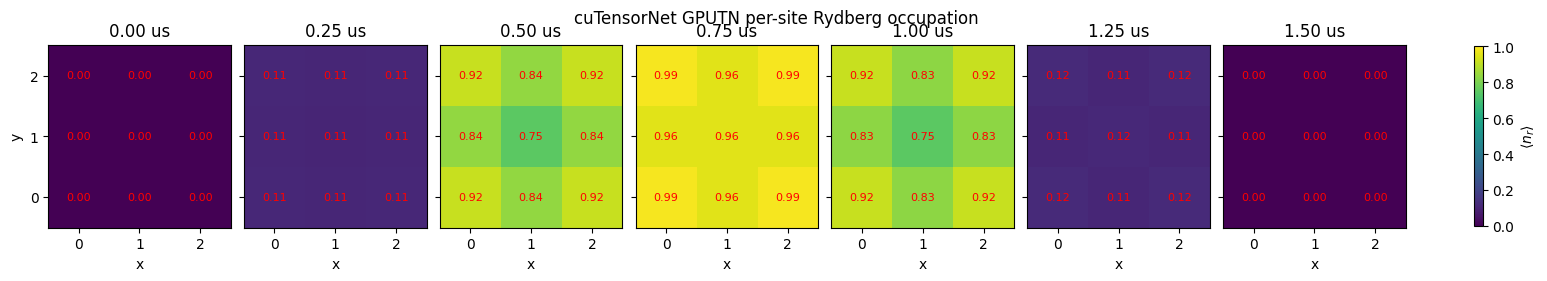

In [ ]:
# 5b. 每个时刻的 4x4 Rydberg occupation color map：使用当前算法的逐格点 <n_r_i>。
fig_h, axes_h = plt.subplots(1, len(t_eval), figsize=(2.2 * len(t_eval), 2.5), constrained_layout=True)
axes_h = np.atleast_1d(axes_h)

for ax_h, t, occ in zip(axes_h, res_gputn.times, gputn_n_i):
    grid = occ.reshape(Lx, Ly)
    im = ax_h.imshow(grid.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
    ax_h.set_title(f"{t * 1e6:.2f} us")
    ax_h.set_xticks(range(Lx))
    ax_h.set_yticks(range(Ly))
    ax_h.set_xlabel("x")
    if ax_h is axes_h[0]:
        ax_h.set_ylabel("y")
    else:
        ax_h.set_yticklabels([])
    for ix in range(Lx):
        for iy in range(Ly):
            val = grid[ix, iy]
            txt_color = "red"
            ax_h.text(ix, iy, f"{val:.2f}", ha="center", va="center", color=txt_color, fontsize=8)

fig_h.colorbar(im, ax=axes_h, shrink=0.82, label=r"$\langle n_r \rangle$")
fig_h.suptitle("cuTensorNet GPUTN per-site Rydberg occupation", y=1.05)
plt.show()


## 6. finite-PEPS (`peps`)

finite-PEPS NTU 路径,保留二维方格几何;默认 NTU 更新 + BP measurement。设 `use_cuda=True, backend_name="torch", device="cuda"` 走 GPU。

In [5]:
# 6a. YASTN finite-PEPS：二维 PEPS 主路径。
method = "peps"
# 开始计时
_t0 = time.perf_counter()

res_peps = rg.simulate(
    system, [], "all_ground",
    backend="peps", t_eval=t_eval, observables=["n_mean", "n_i"],
    backend_options={
        "chi_max": 10,
        "dt": dt_tn,
        "svd_min": 1e-8,
        "measurement_environment": "bp",
        "update_environment": "ntu",
        "max_iter": 10,
        # NTU 每条 bond 的迭代优化停在 tol_iter（相对截断误差不再下降即止），
        # 而非死磕到默认的 1e-12。chi=10 的截断地板 ~1.9e-2，把 tol 放宽到 1e-7
        # 只改变结果 ~7e-5（比地板低 ~250x），却把 evolution_step_ 提速 ~1.5x。
        # 想更激进可设 1e-5（~2x，误差仍 << 地板）；想要严格复现旧值设 1e-12。
        "tol_iter": 1e-7,
        "use_cuda": True,
        "backend_name": "torch",
        "device": "cuda",
    },
)
# 计时结束
peps_elapsed = time.perf_counter() - _t0
# 读取结果
peps_n_mean = np.asarray(res_peps.metadata["obs"]["n_mean"])
peps_n_i = np.asarray(res_peps.metadata["obs"]["n_i"])
# 计算误差
peps_diff_mean = float(np.max(np.abs(peps_n_mean - exact_n_mean))) if "exact_n_mean" in globals() else np.nan
peps_diff_i = float(np.max(np.abs(peps_n_i - exact_n_i))) if "exact_n_i" in globals() else np.nan
print(f"PEPS elapsed: {peps_elapsed:.3f} s")
print("time(us)  exact <n_r>  PEPS <n_r>")
for t, exact_val, p_val in zip(t_eval * 1e6, exact_n_mean, peps_n_mean):
    print(f"{t:7.3f}   {exact_val:10.4f}  {p_val:10.4f}")
print(f"max |delta <n_r>| = {peps_diff_mean:.3e}; max |delta <n_i>| = {peps_diff_i:.3e}")


PEPS elapsed: 1215.100 s
time(us)  exact <n_r>  PEPS <n_r>
  0.000       0.0000      0.0000
  0.250       0.1081      0.1083
  0.500       0.8432      0.8425
  0.750       0.9609      0.9607
  1.000       0.8285      0.8282
  1.250       0.1152      0.1152
  1.500       0.0024      0.0024
max |delta <n_r>| = 6.402e-04; max |delta <n_i>| = 1.082e-03


Loaded saved 10×10 results: scripts/peps_10x10_results.npz
  chi_max=8, elapsed=4.69 h, max_trunc_err=8.21e-04
10×10 PEPS elapsed: 16869.512 s
time(us)  PEPS <n_r>
  0.000       0.0000
  0.250       0.1063
  0.500       0.8044
  0.750       0.9444
  1.000       0.7844
  1.250       0.1104
  1.500       0.0026


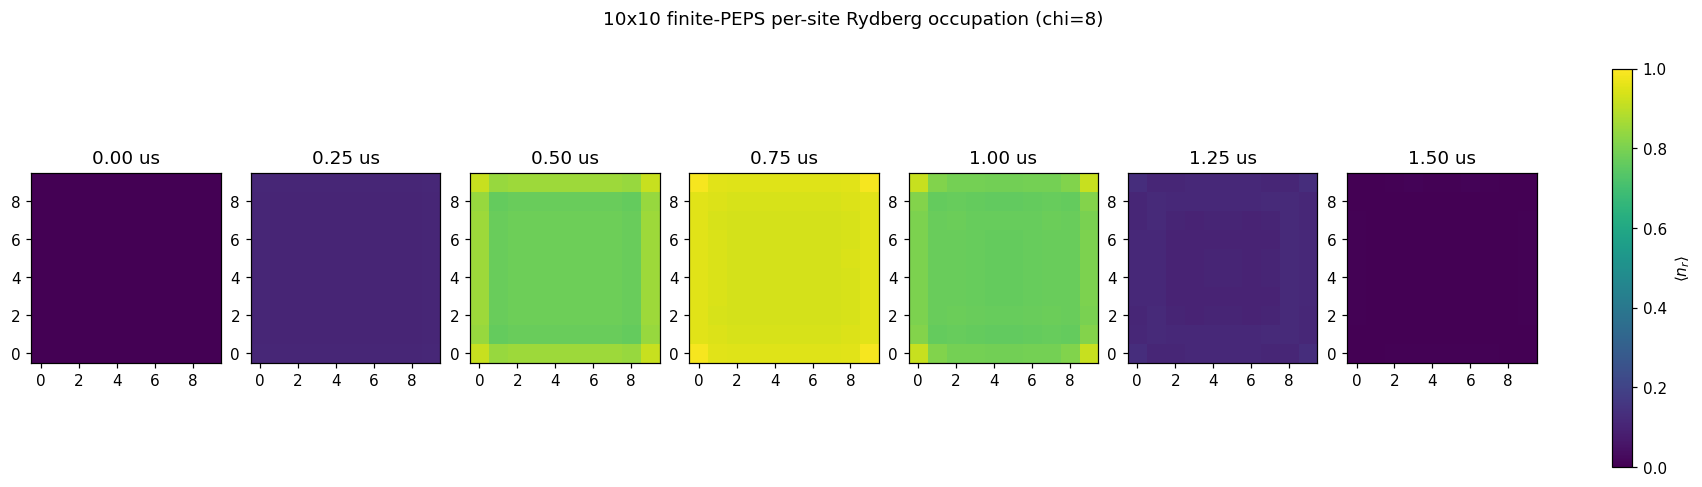

In [ ]:
# 6c. 独立 10×10 finite-PEPS（rydtn 默认 backend，NTU 演化 + boundary-MPS 测量）
# chi_max=8：10×10 每条 bond 饱和到 D=chi_max，NTU 每步成本随 D 陡增。
#   chi=10 → ~8 min/step（~20 h）；chi=8 → ~4.7 h（headless 实测），精度仍 << 占据数量级。
# 完整 headless 运行见 scripts/run_peps_10x10.py；下面优先加载已保存结果，无则现算。
import os

_npz_candidates = [
    "peps_10x10_results.npz",
    "../peps_10x10_results.npz",
    "scripts/peps_10x10_results.npz",
    os.path.expanduser("~/Ryd-gate-modeling/scripts/peps_10x10_results.npz"),
]
_npz = next((p for p in _npz_candidates if os.path.exists(p)), None)

if _npz is not None:
    _d = np.load(_npz)
    Lx_10, Ly_10 = int(_d["Lx"]), int(_d["Ly"])
    peps_10_times = np.asarray(_d["times"])
    peps_10_n_mean = np.asarray(_d["n_mean"])
    peps_10_n_i = np.asarray(_d["n_i"])
    peps_10_elapsed = float(_d["elapsed"])
    print(f"Loaded saved 10×10 results: {_npz}")
    print(f"  chi_max={int(_d['chi_max'])}, elapsed={peps_10_elapsed / 3600:.2f} h, "
          f"max_trunc_err={float(_d['max_truncation_error']):.2e}")
else:
    Lx_10, Ly_10 = 10, 10
    geom_10 = Register.rectangle(Lx_10, Ly_10, spacing_um=a_um)
    protocol_10 = rg.SweepProtocol(
        t_gate=t_sweep, omega_half_fn=omega_half_t, delta_fn=delta_t, n_steps=120,
    )
    system_10 = rg.RydbergSystem.from_lattice(
        geom_10, "1r",
        interaction=InteractionSpec(C6=C6_70s, mode="nn"),
        protocol=protocol_10,
    )
    _t0_10 = time.perf_counter()
    res_peps_10 = rg.simulate(
        system_10, [], "all_ground",
        backend="peps", t_eval=t_eval, observables=["n_mean", "n_i"],
        backend_options={
            "chi_max": 8,            # chi=10 在 10×10 约 20 h；chi=8 约 4.7 h
            "dt": dt_tn,
            "svd_min": 1e-8,
            "measurement_environment": "bp",
            "update_environment": "ntu",
            "max_iter": 10,
            "tol_iter": 1e-7,
            "use_cuda": True,
            "backend_name": "torch",
            "device": "cuda",
        },
    )
    peps_10_elapsed = time.perf_counter() - _t0_10
    peps_10_times = np.asarray(res_peps_10.times)
    peps_10_n_mean = np.asarray(res_peps_10.metadata["obs"]["n_mean"])
    peps_10_n_i = np.asarray(res_peps_10.metadata["obs"]["n_i"])

print(f"10×10 PEPS elapsed: {peps_10_elapsed:.3f} s")
print("time(us)  PEPS <n_r>")
for t, val in zip(peps_10_times * 1e6, peps_10_n_mean):
    print(f"{t:7.3f}   {val:10.4f}")

# 6c-plot. 10×10 逐格点 occupation（chi=8）
fig_h10, axes_h10 = plt.subplots(
    1, len(peps_10_times), figsize=(2.2 * len(peps_10_times), 4.5), constrained_layout=True,
)
axes_h10 = np.atleast_1d(axes_h10)

for ax_h, t, occ in zip(axes_h10, peps_10_times, peps_10_n_i):
    grid = occ.reshape(Lx_10, Ly_10)
    im = ax_h.imshow(grid.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
    ax_h.set_title(f"{t * 1e6:.2f} us")
    ax_h.set_xticks(range(0, Lx_10, 2))
    ax_h.set_yticks(range(0, Ly_10, 2))

fig_h10.colorbar(im, ax=axes_h10, shrink=0.82, label=r"$\langle n_r \rangle$")
fig_h10.suptitle("10×10 finite-PEPS per-site Rydberg occupation (chi=8)", y=1.02)
plt.show()


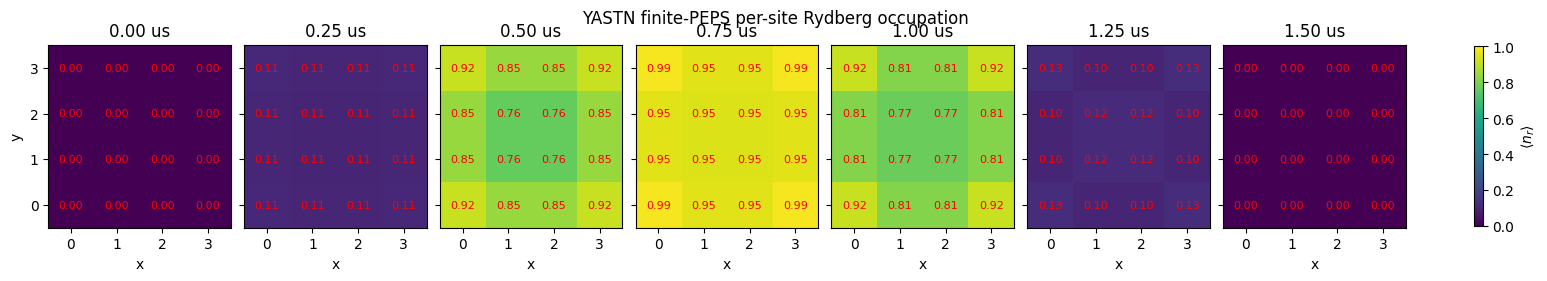

In [6]:
# 6b. 每个时刻的 4x4 Rydberg occupation color map：使用当前算法的逐格点 <n_r_i>。
if peps_n_i is None:
    print("peps has no successful data to plot.")
else:
    fig_h, axes_h = plt.subplots(1, len(t_eval), figsize=(2.2 * len(t_eval), 2.5), constrained_layout=True)
    axes_h = np.atleast_1d(axes_h)

    for ax_h, t, occ in zip(axes_h, res_peps.times, peps_n_i):
        grid = occ.reshape(Lx, Ly)
        im = ax_h.imshow(grid.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
        ax_h.set_title(f"{t * 1e6:.2f} us")
        ax_h.set_xticks(range(Lx))
        ax_h.set_yticks(range(Ly))
        ax_h.set_xlabel("x")
        if ax_h is axes_h[0]:
            ax_h.set_ylabel("y")
        else:
            ax_h.set_yticklabels([])
        for ix in range(Lx):
            for iy in range(Ly):
                val = grid[ix, iy]
                txt_color = "red"
                ax_h.text(ix, iy, f"{val:.2f}", ha="center", va="center", color=txt_color, fontsize=8)

    fig_h.colorbar(im, ax=axes_h, shrink=0.82, label=r"$\langle n_r \rangle$")
    fig_h.suptitle("YASTN finite-PEPS per-site Rydberg occupation", y=1.05)
    plt.show()

## Part B — |+⟩ quench benchmark(finite 3×3, 5 backends + pepskit bulk)

Part A 的三能级 `01r`(`|0>,|1>,|r>`)版本。每个 site 从 `|+>=(|0>+|1>)/√2` 出发,pulse **只驱动 |1>–|r>**(`Omega_hf=0`,0–1 Rabi 关闭、`|0>` 是 spectator),同时扫 Rydberg detuning `Delta_R` 过共振——Rydberg **phase gate**:`|1>` 分支积累相位(单点 + blockade 多体),末态

$$|\psi\rangle \approx \frac{1}{\sqrt{2^N}}\sum_{s\in\{0,1\}^N} e^{i\varphi(s)}\,|s\rangle .$$

画:四个 **finite** 后端(`exact`/`mps`/`peps`/`gputn`)的 per-site $\sqrt{P_{01}}=\sqrt{1-\langle n_r\rangle}$ 2D map;以及 **exact** 的 per-string 累积相位 `φ(s)`(`2⁹=512` strings,唯一暴露全振幅的后端)。`pepskit` 是 infinite/bulk iPEPS(只能 basis-state init)→ 单独 bulk panel 作热力学极限参考。`01r` local dim 3,3×3 是 `3⁹≈19.7k`(4×4 会是 `3¹⁶=43M`)。

In [ ]:
# Pin BLAS/OpenMP to 1 thread BEFORE importing numpy/scipy/tenpy.
# Small TN tensors (DMRG/TDVP/PEPS) => multi-threaded BLAS oversubscribes
# cores and runs 10-40x SLOWER on a loaded box. This cell must stay first
# and run before any import: the libraries read these variables only once,
# at import time.
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(_v, "1")
print("BLAS/OpenMP threads pinned to", os.environ.get("OMP_NUM_THREADS"))

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

import ryd_gate as rg
from ryd_gate import InteractionSpec
from ryd_gate.lattice import Register
from ryd_gate.protocols.digital_analog import DigitalAnalogProtocol

# --- geometry / level structure ---
Lx, Ly = 3, 3
N = Lx * Ly
a_um = 6.8                         # lattice spacing, um
C6 = 2 * np.pi * 874e9             # rad/s * um^6 (Rb 70S typical)

# --- pulse: same shape as run_quench_benchmark but on the |1>-|r> transition.
#     Smooth flat-top Omega_R + cosine round-trip Delta_R (-amp -> +amp -> -amp), so the |1>
#     branch is driven across resonance and back, *returning* population to the qubit subspace
#     with an accumulated phase. Omega_hf = 0 -> the 0-1 Rabi is closed and |0> is a spectator.
Omega_R = 2 * np.pi * 3.8e6        # |1>-|r> Rabi (plateau), rad/s
delta_amp = 2 * np.pi * 8.0e6      # Rydberg detuning amplitude (round trip -amp..+amp..-amp)
t_sweep = 1.5e-6                   # total quench time, s
ramp_frac = 0.15                   # smootherstep edge width of the Omega_R flat-top

def _smootherstep(u):
    u = np.clip(u, 0.0, 1.0)
    return 10 * u**3 - 15 * u**4 + 6 * u**5

def omega_R_at(s):                 # s = t / t_sweep in [0, 1]
    if s < ramp_frac:
        return Omega_R * _smootherstep(s / ramp_frac)
    if s > 1.0 - ramp_frac:
        return Omega_R * _smootherstep((1.0 - s) / ramp_frac)
    return Omega_R

def delta_R_at(s):
    return -delta_amp * np.cos(2.0 * np.pi * s)   # -amp at s=0, +amp at s=0.5, -amp at s=1

n_seg = 80
segments = [
    Segment(duration=t_sweep / n_seg,
            omega_R=omega_R_at((k + 0.5) / n_seg),
            delta_R=delta_R_at((k + 0.5) / n_seg))
    for k in range(n_seg)
]
protocol = segments_protocol(segments)   # Omega_hf defaults to 0 -> 0-1 Rabi closed

geom = Register.rectangle(Lx, Ly, spacing_um=a_um)
system = rg.RydbergSystem.from_lattice(
    geom, "01r",
    interaction=InteractionSpec(C6=C6, mode="nn"),   # nearest-neighbour blockade
    protocol=protocol,
)
t_eval = np.linspace(0.0, t_sweep, 7)
dt_tn = 0.4 / Omega_R              # TN Trotter step (coarse for tractable runtime; 0.2 for production)
V_nn = C6 / a_um**6
tn_results = {}                    # filled by run_tn() below; defined here so §2 plots are robust
print(f"3x3 01r: dim = 3^9 = {3**9};  t_gate = {t_sweep*1e6:.3f} us;  "
      f"n_steps ~ {int(np.ceil(t_sweep/dt_tn))};  V_nn/Omega_R = {V_nn/Omega_R:.2f}")

3x3 01r: dim = 3^9 = 19683;  t_gate = 1.500 us;  n_steps ~ 90;  V_nn/Omega_R = 2.33


In [ ]:
# Local compatibility shim: the kernel DigitalAnalogProtocol is now function-
# based (omega_R_fn(t), ...). These notebooks keep their piecewise-constant
# Segment schedules and lower them to step functions here. Note the backend
# integrates on n_steps uniform slices, so segment edges should be resolved
# by a generous n_steps (the notebooks already scale it with len(segments)).
from dataclasses import dataclass

import numpy as np


@dataclass
class Segment:
    duration: float
    omega_R: "float | np.ndarray" = 0.0
    omega_hf: "float | np.ndarray" = 0.0
    delta_R: "float | np.ndarray" = 0.0
    delta_hf: "float | np.ndarray" = 0.0


def segments_protocol(segments, n_steps=200):
    """Build the function-based DigitalAnalogProtocol from constant segments."""
    segments = list(segments)
    edges = np.cumsum([0.0] + [float(seg.duration) for seg in segments])

    def step_fn(name):
        values = [getattr(seg, name) for seg in segments]

        def fn(t):
            j = int(np.clip(np.searchsorted(edges, t, side="right") - 1, 0, len(values) - 1))
            return values[j]

        return fn

    protocol = DigitalAnalogProtocol(
        t_gate=float(edges[-1]),
        omega_R_fn=step_fn("omega_R"),
        omega_hf_fn=step_fn("omega_hf"),
        delta_R_fn=step_fn("delta_R"),
        delta_hf_fn=step_fn("delta_hf"),
        n_steps=n_steps,
    )
    protocol.segments = segments  # keep the schedule inspectable for plotting
    return protocol


## 1. Exact baseline (full state vector)

`backend="exact"` 在每个 `t_eval` 保留 dense 态矢量,给出 per-site occupation(算 `√P₀₁`)与 §4 用的 per-string 振幅/相位。

In [2]:
_t0 = time.perf_counter()
res_exact = rg.simulate(system, [], "plus", backend="exact", t_eval=t_eval)
exact_elapsed = time.perf_counter() - _t0

d = system.basis.local_dim   # 3, levels ("0","1","r")

def per_site_occ(psi, level):
    return np.array([system.expectation(f"n_{level}_{i}", psi) for i in range(N)])

# sqrt(P_01) per site = sqrt(<n_0> + <n_1>) = sqrt(1 - <n_r>); shape (T, N) in 2D site order.
exact_nr = np.array([per_site_occ(psi, "r") for psi in res_exact.states])
exact_sqrtP01 = np.sqrt(np.clip(1.0 - exact_nr, 0.0, 1.0))
exact_nmean_r = exact_nr.mean(axis=1)

print(f"exact elapsed: {exact_elapsed:.2f} s")
print("t(us)   <n_r>   <n_0>   <n_1>")
for psi, t in zip(res_exact.states, res_exact.times):
    print(f"{t*1e6:6.3f}  {per_site_occ(psi,'r').mean():.4f}  "
          f"{per_site_occ(psi,'0').mean():.4f}  {per_site_occ(psi,'1').mean():.4f}")

exact elapsed: 4.64 s
t(us)   <n_r>   <n_0>   <n_1>
 0.000  0.0000  0.5000  0.5000
 0.248  0.0531  0.5000  0.4469
 0.503  0.2951  0.5000  0.2049
 0.750  0.3346  0.5000  0.1654
 0.998  0.2877  0.5000  0.2123
 1.253  0.0590  0.5000  0.4410
 1.500  0.0150  0.5000  0.4850


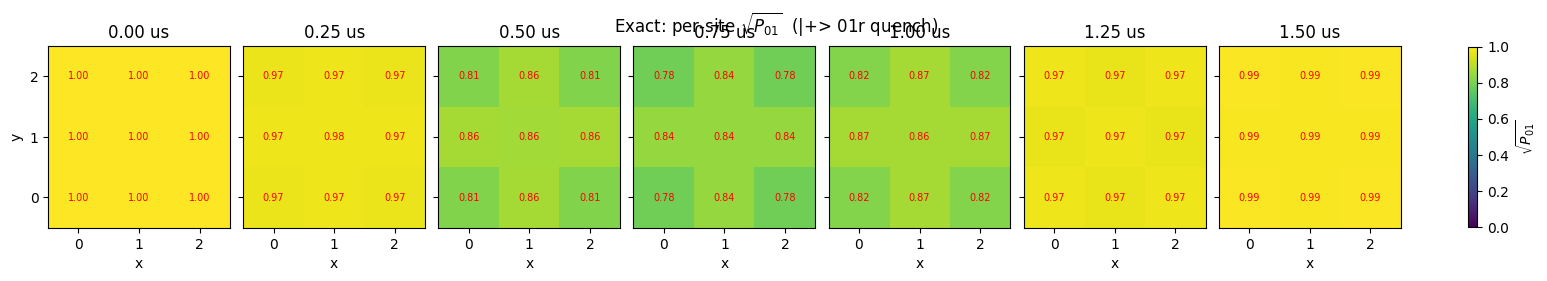

In [3]:
def plot_2d_maps(sqrtP01, times, title):
    # 3x3 per-site color map of sqrt(P_01) at each t_eval (run_quench_benchmark style).
    T = len(times)
    fig, axes = plt.subplots(1, T, figsize=(2.2 * T, 2.5), constrained_layout=True)
    axes = np.atleast_1d(axes)
    im = None
    for ax, t, row in zip(axes, times, sqrtP01):
        grid = np.asarray(row).reshape(Lx, Ly)
        im = ax.imshow(grid.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
        ax.set_title(f"{t*1e6:.2f} us")
        ax.set_xticks(range(Lx)); ax.set_yticks(range(Ly))
        ax.set_xlabel("x")
        ax.set_ylabel("y") if ax is axes[0] else ax.set_yticklabels([])
        for ix in range(Lx):
            for iy in range(Ly):
                ax.text(ix, iy, f"{grid[ix,iy]:.2f}", ha="center", va="center", color="red", fontsize=7)
    fig.colorbar(im, ax=axes, shrink=0.82, label=r"$\sqrt{P_{01}}$")
    fig.suptitle(title, y=1.05)
    plt.show()

plot_2d_maps(exact_sqrtP01, res_exact.times, r"Exact: per-site $\sqrt{P_{01}}$  (|+> 01r quench)")

## 2. Tensor-network backends (finite): `mps`, `peps`, `gputn`

同一 `|+>` quench、同一 `system`。各后端返回 per-site `n_0/n_1/n_r`,据此画 `√P₀₁` 2D map 并把 mean `⟨n_r⟩(t)` 对 exact 比较。`gputn` 强制 exact `statevector` kernel(`auto` 路径在小 lattice 可能 hang);`peps` 跑 CPU(GPU 设 `use_cuda=True, yastn_backend="torch"`)。

/home/chance/Ryd-gate-modeling/.venv/lib/python3.12/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


mps    elapsed:    21.1 s   max|Δ⟨n_r⟩| vs exact = 6.641e-03


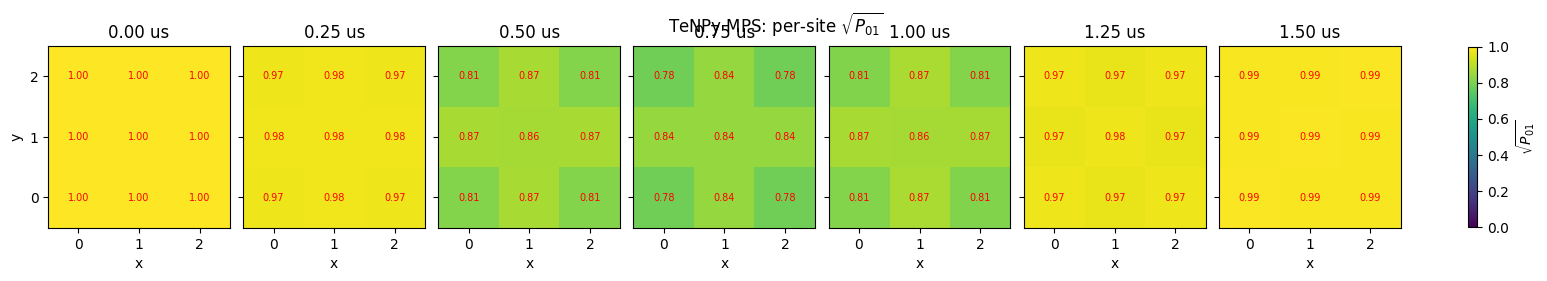

In [4]:
def run_tn(backend, opts):
    _t0 = time.perf_counter()
    res = rg.simulate(
        system, [], "plus", backend=backend, t_eval=t_eval,
        observables=["n_0", "n_1", "n_r"], backend_options=opts,
    )
    elapsed = time.perf_counter() - _t0
    nr = np.asarray(res.metadata["obs"]["n_r"])          # (T, N), 2D site order
    sqrtP01 = np.sqrt(np.clip(1.0 - nr, 0.0, 1.0))
    diff = float(np.max(np.abs(nr.mean(axis=1) - exact_nmean_r)))
    tn_results[backend] = dict(res=res, sqrtP01=sqrtP01, nr_mean=nr.mean(axis=1), elapsed=elapsed, diff=diff)
    print(f"{backend:6s} elapsed: {elapsed:7.1f} s   max|Δ⟨n_r⟩| vs exact = {diff:.3e}")
    return tn_results[backend]

mps = run_tn("mps", {"chi_max": 16, "dt": dt_tn, "svd_min": 1e-10})
plot_2d_maps(mps["sqrtP01"], np.asarray(tn_results["mps"]["res"].times),
             r"TeNPy MPS: per-site $\sqrt{P_{01}}$")

gputn  elapsed:     1.0 s   max|Δ⟨n_r⟩| vs exact = 6.932e-03


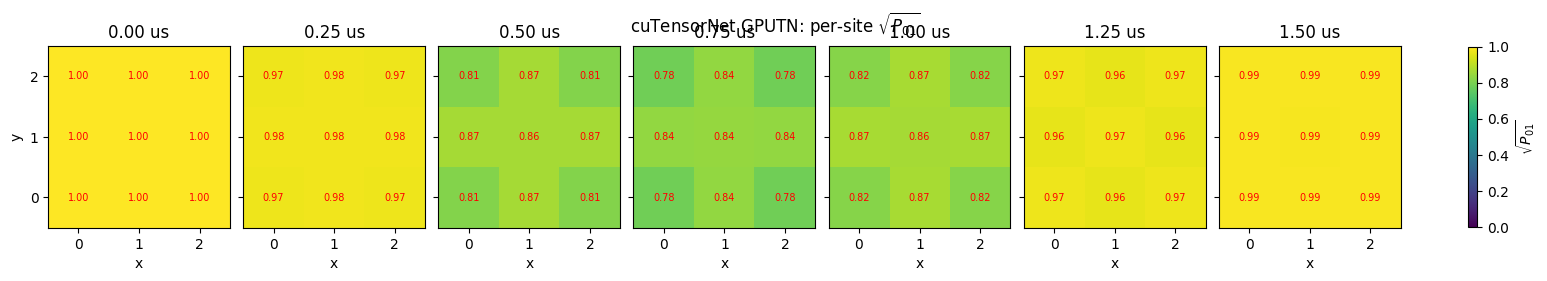

In [5]:
gputn = run_tn("gputn", {"chi_max": 32, "dt": dt_tn, "svd_min": 1e-10,
                          "require_gpu": True, "kernel": "statevector"})
plot_2d_maps(gputn["sqrtP01"], np.asarray(tn_results["gputn"]["res"].times),
             r"cuTensorNet GPUTN: per-site $\sqrt{P_{01}}$")

peps   elapsed:    27.2 s   max|Δ⟨n_r⟩| vs exact = 2.638e-02


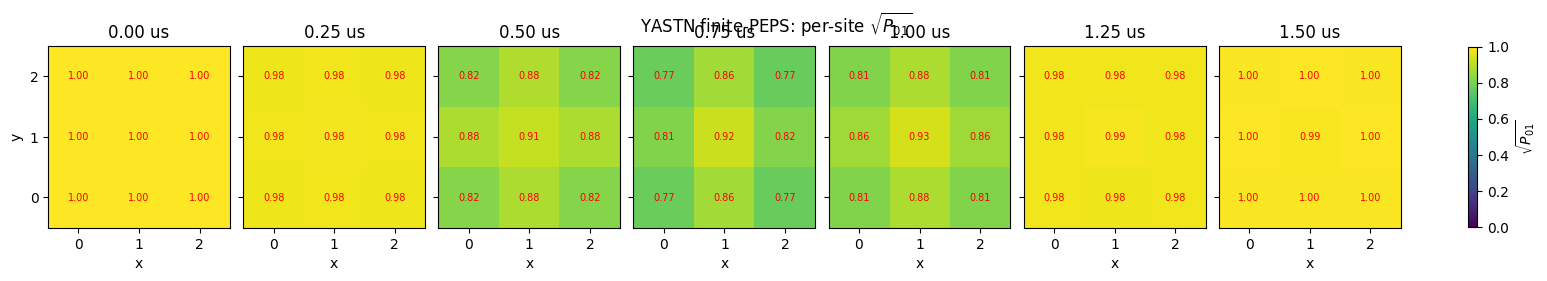

In [6]:
peps = run_tn("peps", {"chi_max": 4, "dt": dt_tn, "svd_min": 1e-8,
                        "measurement_environment": "bp", "update_environment": "ntu",
                        "max_iter": 8, "use_cuda": False})
plot_2d_maps(peps["sqrtP01"], np.asarray(tn_results["peps"]["res"].times),
             r"YASTN finite-PEPS: per-site $\sqrt{P_{01}}$")

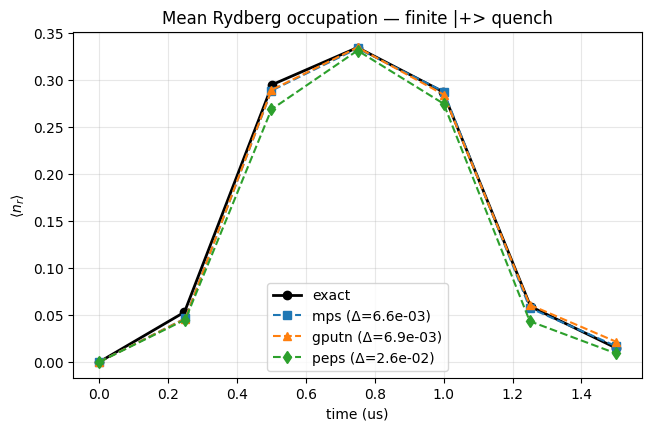

In [7]:
# Agreement check: mean <n_r>(t) across all finite backends (exact = reference).
fig, ax = plt.subplots(figsize=(6.4, 4.2), constrained_layout=True)
ax.plot(res_exact.times * 1e6, exact_nmean_r, "k-o", lw=2, label="exact")
for backend, mk in [("mps", "s--"), ("gputn", "^--"), ("peps", "d--")]:
    if backend in tn_results:
        r = tn_results[backend]
        ax.plot(np.asarray(r["res"].times) * 1e6, r["nr_mean"], mk, label=f"{backend} (Δ={r['diff']:.1e})")
ax.set_xlabel("time (us)"); ax.set_ylabel(r"$\langle n_r \rangle$")
ax.set_title("Mean Rydberg occupation — finite |+> quench"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 3. Per-string accumulated phase `φ(s)`(exact, golden)

把 exact 末态投到 qubit 子空间 `{0,1}⁹`(512 strings):`A_s=⟨s|ψ⟩`,以全-spectator string `|0…0⟩`(冻结)为参考,`φ(s)=arg(A_s·conj(A_{0…0}))`。相位按 Hamming weight `w`(active `|1>` 数)组织:`w=1` 给单比特相位,`w≥2` 给 blockade 多体相位。

In [8]:
# Map each {0,1}^N string -> its index in the 3^N exact basis (level_index 0/1; idx = sum b_i 3^(N-1-i)).
weights3 = np.array([d ** (N - 1 - i) for i in range(N)], dtype=np.int64)
string_idx = np.zeros(2 ** N, dtype=np.int64)
bits_table = np.zeros((2 ** N, N), dtype=np.int8)
for s in range(2 ** N):
    bits = [(s >> (N - 1 - i)) & 1 for i in range(N)]    # site i (2D order) -> bit
    bits_table[s] = bits
    string_idx[s] = int(np.dot(bits, weights3))

def string_phase_prob(psi):
    amps = np.asarray(psi)[string_idx]
    ref = amps[0]                                         # |0...0>
    phi = np.angle(amps * np.conj(ref))
    return phi, np.abs(amps) ** 2

phi, prob = string_phase_prob(res_exact.states[-1])
weight = bits_table.sum(axis=1)
P_subspace = prob.sum()
print(f"qubit-subspace probability at t_gate = {P_subspace:.4f}  "
      f"(leakage to |r> = {1 - P_subspace:.4f})")
print(f"single-site phase  <φ(w=1)> = {phi[weight==1].mean():+.4f} rad  "
      f"(spread {phi[weight==1].std():.1e})")
# NN vs non-NN pair extra phase (φ_pair - 2*φ_single):
nn = {(min(int(i), int(j)), max(int(i), int(j))) for i, j, _v in system.meta('interaction_pairs', ())}
single = phi[weight == 1].mean()
w2 = np.where(weight == 2)[0]
pair_extra_nn, pair_extra_far = [], []
for s in w2:
    i, j = np.where(bits_table[s] == 1)[0]
    extra = phi[s] - 2 * single
    (pair_extra_nn if (int(i), int(j)) in nn else pair_extra_far).append(extra)
print(f"pair extra phase  NN: {np.mean(pair_extra_nn):+.4f} rad   "
      f"non-NN: {np.mean(pair_extra_far):+.4f} rad")

qubit-subspace probability at t_gate = 0.8699  (leakage to |r> = 0.1301)
single-site phase  <φ(w=1)> = -0.7349 rad  (spread 0.0e+00)
pair extra phase  NN: -1.6565 rad   non-NN: -0.0000 rad


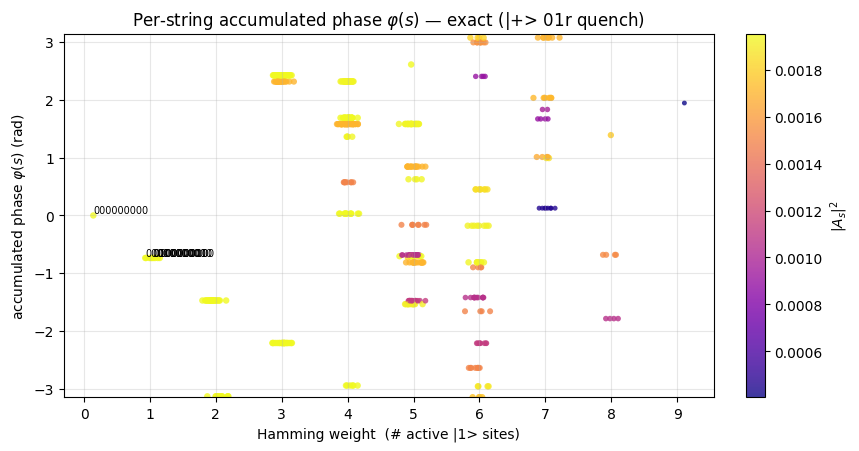

Representative low-weight strings (site order = row-major 3x3):
  string       w   φ(rad)     |A|^2
  000000000   0   -0.0000  0.0020
  000000001   1   -0.7349  0.0020
  000000010   1   -0.7349  0.0020
  000000100   1   -0.7349  0.0020
  000001000   1   -0.7349  0.0020
  000010000   1   -0.7349  0.0020
  000100000   1   -0.7349  0.0020
  001000000   1   -0.7349  0.0020
  010000000   1   -0.7349  0.0020
  100000000   1   -0.7349  0.0020


In [9]:
# Scatter: phase vs Hamming weight, marker size/colour ~ |A_s|^2; dominant strings labelled.
rng = np.random.RandomState(0)
jitter = 0.08 * rng.randn(2 ** N)
fig, ax = plt.subplots(figsize=(8.5, 4.4), constrained_layout=True)
sc = ax.scatter(weight + jitter, phi, c=prob, s=10 + 6000 * prob, cmap="plasma", alpha=0.8, edgecolors="none")
ax.set_xlabel("Hamming weight  (# active |1> sites)")
ax.set_ylabel(r"accumulated phase $\varphi(s)$ (rad)")
ax.set_title(r"Per-string accumulated phase $\varphi(s)$ — exact (|+> 01r quench)")
ax.set_xticks(range(N + 1)); ax.grid(alpha=0.3)
ax.set_ylim(-np.pi, np.pi)
fig.colorbar(sc, ax=ax, label=r"$|A_s|^2$")
for s in np.argsort(prob)[::-1][:6]:                     # label the dominant strings
    ax.annotate("".join(map(str, bits_table[s])), (weight[s] + jitter[s], phi[s]),
                fontsize=7, ha="left", va="bottom")
plt.show()

print("Representative low-weight strings (site order = row-major 3x3):")
print("  string       w   φ(rad)     |A|^2")
for s in list(np.where(weight == 0)[0]) + list(np.where(weight == 1)[0]):
    print(f"  {''.join(map(str, bits_table[s]))}  {weight[s]:2d}  {phi[s]:+8.4f}  {prob[s]:.4f}")

## 4. `pepskit` iPEPS — bulk(热力学极限)参考

`pepskit` 是 infinite iPEPS(2×2 平移不变 unit cell、basis-state init),无法表示有限 `|+>` 态或 per-string 相位——单独 bulk panel:同一 pulse 从 `|1>` 出发、报告 bulk occupation。需 Julia + PEPSKit.jl(首调付 JIT cold-start),guarded 以便 Julia 不可用时 notebook 仍跑完。

pepskit bulk elapsed: 106.7 s


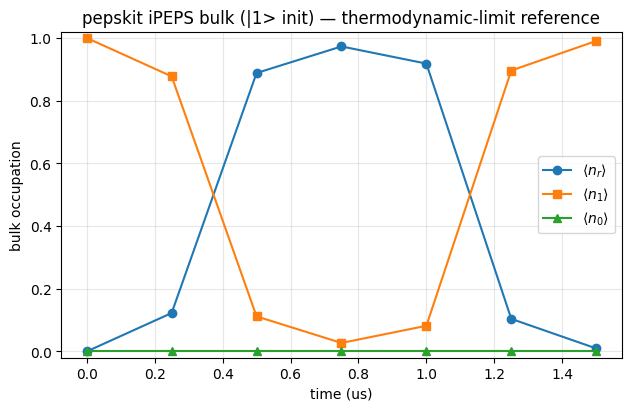

In [10]:
# Bulk iPEPS uses a 2x2 unit cell; build a matching 2x2 01r system with the same pulse.
bulk_system = rg.RydbergSystem.from_lattice(
    Register.rectangle(2, 2, spacing_um=a_um), "01r",
    interaction=InteractionSpec(C6=C6, mode="nn"), protocol=protocol,
)
try:
    _t0 = time.perf_counter()
    res_bulk = rg.simulate(
        bulk_system, [], "all_1", backend="pepskit", t_eval=t_eval,
        observables=["n_r", "n_1", "n_0"],
        backend_options={"unit_cell": "uniform", "bond_dim": 3, "env_dim": 16, "dt": dt_tn, "timeout": 1800},
    )
    print(f"pepskit bulk elapsed: {time.perf_counter() - _t0:.1f} s")
    bt = np.asarray(res_bulk.times) * 1e6
    fig, ax = plt.subplots(figsize=(6.2, 4.0), constrained_layout=True)
    for key, mk in [("n_r", "o-"), ("n_1", "s-"), ("n_0", "^-")]:
        ax.plot(bt, np.asarray(res_bulk.metadata["obs"][key]), mk, label=fr"$\langle n_{{{key[-1]}}} \rangle$")
    ax.set_xlabel("time (us)"); ax.set_ylabel("bulk occupation")
    ax.set_title("pepskit iPEPS bulk (|1> init) — thermodynamic-limit reference")
    ax.set_ylim(-0.02, 1.02); ax.legend(); ax.grid(alpha=0.3)
    plt.show()
except Exception as exc:
    print("pepskit bulk panel skipped:", repr(exc)[:300])

## Part C — Plus-state preparation(制备 + sublattice-X echo + 制备后 Ising 演化)

In [ ]:
# Pin BLAS/OpenMP to 1 thread BEFORE importing numpy/scipy/tenpy.
# Small TN tensors (DMRG/TDVP/PEPS) => multi-threaded BLAS oversubscribes
# cores and runs 10-40x SLOWER on a loaded box. This cell must stay first
# and run before any import: the libraries read these variables only once,
# at import time.
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(_v, "1")
print("BLAS/OpenMP threads pinned to", os.environ.get("OMP_NUM_THREADS"))

In [ ]:
import os
import time
from pathlib import Path
from itertools import product

import numpy as np
import matplotlib.pyplot as plt

os.environ.setdefault("CUPY_CACHE_DIR", str(Path.cwd() / ".cache" / "cupy"))
Path(os.environ["CUPY_CACHE_DIR"]).mkdir(parents=True, exist_ok=True)

from ryd_gate import DEFAULT_C6, RydbergSystem, simulate
from ryd_gate.lattice import Register
from ryd_gate import InteractionSpec
from ryd_gate.protocols.digital_analog import DigitalAnalogProtocol
from ryd_gate.backends.tenpy_mps import mps_fidelity, product_superposition_mps
from ryd_gate.backends.tn_common.compiler import tn_lattice_spec_from_system


In [ ]:
# Local compatibility shim: the kernel DigitalAnalogProtocol is now function-
# based (omega_R_fn(t), ...). These notebooks keep their piecewise-constant
# Segment schedules and lower them to step functions here. Note the backend
# integrates on n_steps uniform slices, so segment edges should be resolved
# by a generous n_steps (the notebooks already scale it with len(segments)).
from dataclasses import dataclass

import numpy as np


@dataclass
class Segment:
    duration: float
    omega_R: "float | np.ndarray" = 0.0
    omega_hf: "float | np.ndarray" = 0.0
    delta_R: "float | np.ndarray" = 0.0
    delta_hf: "float | np.ndarray" = 0.0


def segments_protocol(segments, n_steps=200):
    """Build the function-based DigitalAnalogProtocol from constant segments."""
    segments = list(segments)
    edges = np.cumsum([0.0] + [float(seg.duration) for seg in segments])

    def step_fn(name):
        values = [getattr(seg, name) for seg in segments]

        def fn(t):
            j = int(np.clip(np.searchsorted(edges, t, side="right") - 1, 0, len(values) - 1))
            return values[j]

        return fn

    protocol = DigitalAnalogProtocol(
        t_gate=float(edges[-1]),
        omega_R_fn=step_fn("omega_R"),
        omega_hf_fn=step_fn("omega_hf"),
        delta_R_fn=step_fn("delta_R"),
        delta_hf_fn=step_fn("delta_hf"),
        n_steps=n_steps,
    )
    protocol.segments = segments  # keep the schedule inspectable for plotting
    return protocol


### Plus-state preparation benchmark

完整 Hamiltonian:
$$
H(t)/\hbar = \sum_i \frac{\Omega_{R,i}(t)}{2}\left(|r_i\rangle\langle 1_i|+\mathrm{h.c.}\right) -\sum_i \Delta_{R,i}(t)\,n_i^r +\sum_i \frac{\Omega_{\rm hf,i}(t)}{2}\left(|1_i\rangle\langle 0_i|+\mathrm{h.c.}\right) -\sum_i \Delta_{\rm hf,i}(t)\,n_i^1 +\sum_{i<j}V_{ij}\,n_i^r n_j^r .
$$

每个后端一个可执行 block,无 `RUN_*` 开关。所有 TN 比较用最近邻 interaction(`mode="nn"`),让 TN 算法看到 local Hamiltonian、比较同一物理。相关 TN 路径:`mps`(TeNPy)、`peps`(YASTN finite)、`gputn`(CUDA experimental)。

In [ ]:
# Physical parameters and the two-stage pulse shape.
OMEGA_R = 2 * np.pi * 6e6
OMEGA_HF = 2 * np.pi * 6e6

t_pi_R = np.pi / OMEGA_R
t_pi2_R = np.pi / (2 * OMEGA_R)

DELTA_R_ISING = 2 * np.pi * 1.0e6
T_ISING = 1.0e-6

full_segments = [
    Segment(duration=t_pi2_R, omega_R=OMEGA_R),
    Segment(
        duration=T_ISING,
        omega_R=0.0,
        omega_hf=0.0,
        delta_R=DELTA_R_ISING,
        delta_hf=0.0,
    ),
]

t_prep_end = full_segments[0].duration
t_final = sum(seg.duration for seg in full_segments)
_proto_fields = (
    ("omega_R", r"$\Omega_R$"),
    ("omega_hf", r"$\Omega_{\rm hf}$"),
    ("delta_R", r"$\Delta_R$"),
    ("delta_hf", r"$\Delta_{\rm hf}$"),
)

_t_edges = [0.0]
for seg in full_segments:
    _t_edges.append(_t_edges[-1] + seg.duration)

fig_p, axes_p = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
for ax_p, (field, label) in zip(axes_p, _proto_fields):
    t_pts, y_pts = [], []
    for j, seg in enumerate(full_segments):
        v = getattr(seg, field)
        t_pts.extend([_t_edges[j], _t_edges[j + 1]])
        y_pts.extend([v, v])
    ax_p.step(t_pts, y_pts, where="post", lw=2, color="tab:blue")
    ax_p.axhline(0.0, color="k", ls=":", lw=0.8)
    ax_p.axvline(t_prep_end, color="tab:orange", ls="--", lw=1, alpha=0.8)
    ax_p.set_ylabel(label)
    ax_p.grid(alpha=0.3)
    ax_p.set_xlim(0.0, t_final)

axes_p[-1].set_xlabel("time (s)")
axes_p[-1].axvline(t_final, color="tab:green", ls="--", lw=1, alpha=0.8)
fig_p.suptitle("Pulse-time shape", y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# Common plus-preparation system.  All benchmark backends below use this same nn Hamiltonian.
Lx, Ly = 3, 3
spacing = 10.0
N = Lx * Ly
interaction_mode = "nn"

prep_steps = 200
prep_proto = segments_protocol([full_segments[0]], n_steps=prep_steps)
geom = Register.rectangle(Lx, Ly, spacing_um=spacing)
prep_system = RydbergSystem.from_lattice(
    geom,
    level_structure="01r",
    interaction=InteractionSpec(C6=DEFAULT_C6, mode=interaction_mode),
    protocol=prep_proto,
    Omega=OMEGA_R,
)
t_eval_prep = np.linspace(0.0, t_pi2_R, 101)

# Exact target in the full 01r Hilbert space: product_i (|1> - i|r>) / sqrt(2).
plus_target_exact = sum(
    (-1j) ** sum(c == "r" for c in cfg) * prep_system.product_state(list(cfg))
    for cfg in product(["1", "r"], repeat=N)
) / (2 ** (N / 2))

# TeNPy/MPS target for TN fidelity checks.
prep_spec = tn_lattice_spec_from_system(prep_system)
plus_target_mps = product_superposition_mps(
    prep_spec,
    zero_amp=0.0,
    ground_amp=1 / np.sqrt(2),
    rydberg_amp=-1j / np.sqrt(2),
)

plus_results = {}
print(f"Plus-prep benchmark: {Lx}x{Ly}, level_structure=01r, interaction={interaction_mode}, steps={prep_steps}")
print(f"t_pi2_R = {t_pi2_R:.3e} s")


## Exact sparse-expm baseline

同样最近邻 Hamiltonian 的 exact 态矢量演化——observable 与 target-state fidelity 的基准。

In [ ]:
# Exact sparse-expm plus-state preparation.
backend_name = "sparse_expm"
_t0 = time.perf_counter()
res_prep_exact = simulate(
    prep_system,
    [],
    "all_1",
    backend=backend_name,
    backend_options={"n_steps": prep_proto.n_steps},
    t_eval=t_eval_prep,
)
elapsed = time.perf_counter() - _t0

psi0 = prep_system.product_state(["1"] * N)
t_prep = np.concatenate([[0.0], res_prep_exact.times])
states = [psi0, *res_prep_exact.states]
n_0_prep = np.array([[prep_system.expectation(f"n_0_{i}", psi) for i in range(N)] for psi in states])
n_1_prep = np.array([[prep_system.expectation(f"n_1_{i}", psi) for i in range(N)] for psi in states])
n_r_prep = np.array([[prep_system.expectation(f"n_r_{i}", psi) for i in range(N)] for psi in states])
psi_plus_exact = res_prep_exact.psi_final
fid_prep = float(np.abs(np.vdot(plus_target_exact, psi_plus_exact)) ** 2)

plus_results[backend_name] = {
    "status": "ok",
    "elapsed_s": elapsed,
    "fidelity": fid_prep,
    "times": t_prep,
    "n_0": n_0_prep,
    "n_1": n_1_prep,
    "n_r": n_r_prep,
    "final_n_r_mean": float(n_r_prep[-1].mean()),
    "max_mean_diff_vs_exact": 0.0,
    "max_site_diff_vs_exact": 0.0,
}

print(f"{backend_name}: time={elapsed:.3f} s, F={fid_prep:.6f}, final mean <n_r>={n_r_prep[-1].mean():.6f}")

BS = chr(92)
colors = {"0": "tab:gray", "1": "tab:blue", "r": "tab:red"}
fig, axes = plt.subplots(Ly, Lx, figsize=(3.5 * Lx, 3 * Ly), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(Ly, Lx)
for i in range(N):
    ix, iy = i // Ly, i % Ly
    ax = axes[iy, ix]
    ax.plot(t_prep, n_0_prep[:, i], color=colors["0"], lw=2, label=f"${BS}langle n_0{BS}rangle$")
    ax.plot(t_prep, n_1_prep[:, i], color=colors["1"], lw=2, label=f"${BS}langle n_1{BS}rangle$")
    ax.plot(t_prep, n_r_prep[:, i], color=colors["r"], lw=2, label=f"${BS}langle n_r{BS}rangle$")
    ax.axhline(0.5, color="k", ls=":", lw=1)
    ax.set_title(f"({ix}, {iy})")
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(loc="upper right", ncol=3)
for ax in axes[-1, :]:
    ax.set_xlabel("time (s)")
fig.suptitle(f"{Lx}x{Ly} plus-state preparation: local populations ({backend_name}, {interaction_mode})")
plt.tight_layout()
plt.show()


## TeNPy MPS-TDVP (`mps`)


In [ ]:
# TeNPy MPS-TDVP plus-state preparation.
backend_name = "mps"
backend_opts = {
    "chi_max": 128,
    "dt": t_pi2_R / prep_proto.n_steps,
    "svd_min": 1e-10,
}
_t0 = time.perf_counter()
res_prep_tenpy = simulate(
    prep_system,
    [],
    "all_1",
    backend=backend_name,
    backend_options=backend_opts,
    method="tdvp",
    t_eval=t_eval_prep,
    observables=["n_0", "n_1", "n_i", "n_mean"],
)
elapsed = time.perf_counter() - _t0

t_prep = np.asarray(res_prep_tenpy.times, dtype=float)
n_0_prep = np.asarray(res_prep_tenpy.metadata["obs"]["n_0"], dtype=float)
n_1_prep = np.asarray(res_prep_tenpy.metadata["obs"]["n_1"], dtype=float)
n_r_prep = np.asarray(res_prep_tenpy.metadata["obs"]["n_i"], dtype=float)
psi_plus_tenpy = res_prep_tenpy.psi_final
fid_prep = mps_fidelity(plus_target_mps, psi_plus_tenpy)

max_mean_diff = np.nan
max_site_diff = np.nan
if "sparse_expm" in plus_results and plus_results["sparse_expm"]["status"] == "ok":
    ref_t = plus_results["sparse_expm"]["times"]
    ref_n = plus_results["sparse_expm"]["n_r"]
    ref_match = np.asarray([ref_n[int(np.argmin(np.abs(ref_t - t)))] for t in t_prep])
    max_mean_diff = float(np.max(np.abs(n_r_prep.mean(axis=1) - ref_match.mean(axis=1))))
    max_site_diff = float(np.max(np.abs(n_r_prep - ref_match)))

plus_results[backend_name] = {
    "status": "ok",
    "elapsed_s": elapsed,
    "fidelity": fid_prep,
    "times": t_prep,
    "n_0": n_0_prep,
    "n_1": n_1_prep,
    "n_r": n_r_prep,
    "final_n_r_mean": float(n_r_prep[-1].mean()),
    "max_mean_diff_vs_exact": max_mean_diff,
    "max_site_diff_vs_exact": max_site_diff,
}

print(f"{backend_name}: time={elapsed:.3f} s, F={fid_prep:.6f}, final mean <n_r>={n_r_prep[-1].mean():.6f}")
print(f"max |mean <n_r> - exact|={max_mean_diff:.3e}, max site diff={max_site_diff:.3e}")

BS = chr(92)
colors = {"0": "tab:gray", "1": "tab:blue", "r": "tab:red"}
fig, axes = plt.subplots(Ly, Lx, figsize=(3.5 * Lx, 3 * Ly), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(Ly, Lx)
for i in range(N):
    ix, iy = i // Ly, i % Ly
    ax = axes[iy, ix]
    ax.plot(t_prep, n_0_prep[:, i], color=colors["0"], lw=2, label=f"${BS}langle n_0{BS}rangle$")
    ax.plot(t_prep, n_1_prep[:, i], color=colors["1"], lw=2, label=f"${BS}langle n_1{BS}rangle$")
    ax.plot(t_prep, n_r_prep[:, i], color=colors["r"], lw=2, label=f"${BS}langle n_r{BS}rangle$")
    ax.axhline(0.5, color="k", ls=":", lw=1)
    ax.set_title(f"({ix}, {iy})")
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(loc="upper right", ncol=3)
for ax in axes[-1, :]:
    ax.set_xlabel("time (s)")
fig.suptitle(f"{Lx}x{Ly} plus-state preparation: local populations ({backend_name}, {interaction_mode})")
plt.tight_layout()
plt.show()


## YASTN finite PEPS (`peps`)

同一最近邻 `01r` 问题,YASTN finite-PEPS:保留二维几何、local dim `d=3`;报告对 exact 的 observable 一致性(非 target-state fidelity)。

In [ ]:
# YASTN finite-PEPS plus-state preparation.
backend_name = "peps"
backend_opts = {
    "chi_max": 8,
    "dt": t_pi2_R / prep_proto.n_steps,
    "svd_min": 1e-10,
    "update_environment": "ntu",
    "measurement_environment": "bp",
    "use_cuda": False,
}
_t0 = time.perf_counter()
try:
    res_prep_peps = simulate(
        prep_system,
        [],
        "all_1",
        backend=backend_name,
        backend_options=backend_opts,
        method="tdvp",
        t_eval=t_eval_prep,
        observables=["n_0", "n_1", "n_r", "n_mean"],
    )
    elapsed = time.perf_counter() - _t0

    t_prep = np.asarray(res_prep_peps.times, dtype=float)
    n_0_prep = np.asarray(res_prep_peps.metadata["obs"]["n_0"], dtype=float)
    n_1_prep = np.asarray(res_prep_peps.metadata["obs"]["n_1"], dtype=float)
    n_r_prep = np.asarray(res_prep_peps.metadata["obs"]["n_r"], dtype=float)

    max_mean_diff = np.nan
    max_site_diff = np.nan
    if "sparse_expm" in plus_results and plus_results["sparse_expm"]["status"] == "ok":
        ref_t = plus_results["sparse_expm"]["times"]
        ref_n = plus_results["sparse_expm"]["n_r"]
        ref_match = np.asarray([ref_n[int(np.argmin(np.abs(ref_t - t)))] for t in t_prep])
        max_mean_diff = float(np.max(np.abs(n_r_prep.mean(axis=1) - ref_match.mean(axis=1))))
        max_site_diff = float(np.max(np.abs(n_r_prep - ref_match)))

    plus_results[backend_name] = {
        "status": "ok",
        "elapsed_s": elapsed,
        "fidelity": np.nan,
        "times": t_prep,
        "n_0": n_0_prep,
        "n_1": n_1_prep,
        "n_r": n_r_prep,
        "final_n_r_mean": float(n_r_prep[-1].mean()),
        "max_mean_diff_vs_exact": max_mean_diff,
        "max_site_diff_vs_exact": max_site_diff,
    }

    print(f"{backend_name}: time={elapsed:.3f} s, final mean <n_r>={n_r_prep[-1].mean():.6f}")
    print(f"max |mean <n_r> - exact|={max_mean_diff:.3e}, max site diff={max_site_diff:.3e}")

    BS = chr(92)
    colors = {"0": "tab:gray", "1": "tab:blue", "r": "tab:red"}
    fig, axes = plt.subplots(Ly, Lx, figsize=(3.5 * Lx, 3 * Ly), sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(Ly, Lx)
    for i in range(N):
        ix, iy = i // Ly, i % Ly
        ax = axes[iy, ix]
        ax.plot(t_prep, n_0_prep[:, i], color=colors["0"], lw=2, label=f"${BS}langle n_0{BS}rangle$")
        ax.plot(t_prep, n_1_prep[:, i], color=colors["1"], lw=2, label=f"${BS}langle n_1{BS}rangle$")
        ax.plot(t_prep, n_r_prep[:, i], color=colors["r"], lw=2, label=f"${BS}langle n_r{BS}rangle$")
        ax.axhline(0.5, color="k", ls=":", lw=1)
        ax.set_title(f"({ix}, {iy})")
        ax.grid(alpha=0.3)
        if i == 0:
            ax.legend(loc="upper right", ncol=3)
    for ax in axes[-1, :]:
        ax.set_xlabel("time (s)")
    fig.suptitle(f"{Lx}x{Ly} plus-state preparation: local populations ({backend_name}, {interaction_mode})")
    plt.tight_layout()
    plt.show()

except Exception as exc:
    elapsed = time.perf_counter() - _t0
    plus_results[backend_name] = {
        "status": "failed",
        "elapsed_s": elapsed,
        "error": repr(exc),
        "fidelity": np.nan,
        "final_n_r_mean": np.nan,
        "max_mean_diff_vs_exact": np.nan,
        "max_site_diff_vs_exact": np.nan,
    }
    print(f"{backend_name}: failed after {elapsed:.3f} s")
    print(repr(exc))


## CUDA GPUTN

同一最近邻 `01r` 的 CUDA GPUTN 路径。缺 CUDA/cuQuantum 时打印依赖错误、记录状态,不影响其它结果。

In [ ]:
# CUDA GPUTN plus-state preparation.
backend_name = "gputn"
backend_opts = {
    "chi_max": 128,
    "dt": t_pi2_R / prep_proto.n_steps,
    "svd_min": 1e-10,
    "device_id": 0,
    "require_gpu": True,
    "kernel": "statevector",
}

_t0 = time.perf_counter()
try:
    res_prep_gputn = simulate(
        prep_system,
        [],
        "all_1",
        backend=backend_name,
        backend_options=backend_opts,
        method="tdvp",
        t_eval=t_eval_prep,
        observables=["n_0", "n_1", "n_i", "n_mean"],
    )
    elapsed = time.perf_counter() - _t0

    t_prep = np.asarray(res_prep_gputn.times, dtype=float)
    n_0_prep = np.asarray(res_prep_gputn.metadata["obs"]["n_0"], dtype=float)
    n_1_prep = np.asarray(res_prep_gputn.metadata["obs"]["n_1"], dtype=float)
    n_r_prep = np.asarray(res_prep_gputn.metadata["obs"]["n_i"], dtype=float)

    max_mean_diff = np.nan
    max_site_diff = np.nan
    if "sparse_expm" in plus_results and plus_results["sparse_expm"]["status"] == "ok":
        ref_t = plus_results["sparse_expm"]["times"]
        ref_n = plus_results["sparse_expm"]["n_r"]
        ref_match = np.asarray([ref_n[int(np.argmin(np.abs(ref_t - t)))] for t in t_prep])
        max_mean_diff = float(np.max(np.abs(n_r_prep.mean(axis=1) - ref_match.mean(axis=1))))
        max_site_diff = float(np.max(np.abs(n_r_prep - ref_match)))

    plus_results[backend_name] = {
        "status": "ok",
        "elapsed_s": elapsed,
        "fidelity": np.nan,
        "times": t_prep,
        "n_0": n_0_prep,
        "n_1": n_1_prep,
        "n_r": n_r_prep,
        "final_n_r_mean": float(n_r_prep[-1].mean()),
        "max_mean_diff_vs_exact": max_mean_diff,
        "max_site_diff_vs_exact": max_site_diff,
    }

    print(f"{backend_name}: time={elapsed:.3f} s, final mean <n_r>={n_r_prep[-1].mean():.6f}")
    print(f"max |mean <n_r> - exact|={max_mean_diff:.3e}, max site diff={max_site_diff:.3e}")

    BS = chr(92)
    colors = {"0": "tab:gray", "1": "tab:blue", "r": "tab:red"}
    fig, axes = plt.subplots(Ly, Lx, figsize=(3.5 * Lx, 3 * Ly), sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(Ly, Lx)
    for i in range(N):
        ix, iy = i // Ly, i % Ly
        ax = axes[iy, ix]
        ax.plot(t_prep, n_0_prep[:, i], color=colors["0"], lw=2, label=f"${BS}langle n_0{BS}rangle$")
        ax.plot(t_prep, n_1_prep[:, i], color=colors["1"], lw=2, label=f"${BS}langle n_1{BS}rangle$")
        ax.plot(t_prep, n_r_prep[:, i], color=colors["r"], lw=2, label=f"${BS}langle n_r{BS}rangle$")
        ax.axhline(0.5, color="k", ls=":", lw=1)
        ax.set_title(f"({ix}, {iy})")
        ax.grid(alpha=0.3)
        if i == 0:
            ax.legend(loc="upper right", ncol=3)
    for ax in axes[-1, :]:
        ax.set_xlabel("time (s)")
    fig.suptitle(f"{Lx}x{Ly} plus-state preparation: local populations ({backend_name}, {interaction_mode})")
    plt.tight_layout()
    plt.show()

except Exception as exc:
    elapsed = time.perf_counter() - _t0
    plus_results[backend_name] = {
        "status": "failed",
        "elapsed_s": elapsed,
        "error": repr(exc),
        "fidelity": np.nan,
        "final_n_r_mean": np.nan,
        "max_mean_diff_vs_exact": np.nan,
        "max_site_diff_vs_exact": np.nan,
    }
    print(f"{backend_name}: failed after {elapsed:.3f} s")
    print(repr(exc))


## Backend comparison

在上面各后端 block 之后运行:打印 timing/error 列表,画 runtime 与 observable 一致性。最快成功方法 = 表中 wall time 最小者。

In [ ]:
# Compare backend timing and consistency.
print("backend        status       time(s)    fidelity    final <n_r>    max mean diff    max site diff")
for name, row in plus_results.items():
    elapsed = row.get("elapsed_s", np.nan)
    fid = row.get("fidelity", np.nan)
    final_mean = row.get("final_n_r_mean", np.nan)
    mean_diff = row.get("max_mean_diff_vs_exact", np.nan)
    site_diff = row.get("max_site_diff_vs_exact", np.nan)
    print(
        f"{name:<14} {row.get('status', ''):<10} "
        f"{elapsed:9.3f}  {fid:10.6f}  {final_mean:12.6f}  "
        f"{mean_diff:13.3e}  {site_diff:13.3e}"
    )

ok_names = [name for name, row in plus_results.items() if row.get("status") == "ok"]
if ok_names:
    fastest = min(ok_names, key=lambda name: plus_results[name]["elapsed_s"])
    print(f"\nFastest successful backend: {fastest}")

    fig_cmp, axes_cmp = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    axes_cmp[0].bar(ok_names, [plus_results[name]["elapsed_s"] for name in ok_names], color="tab:blue", alpha=0.8)
    axes_cmp[0].set_ylabel("wall time (s)")
    axes_cmp[0].set_title("Runtime")
    axes_cmp[0].tick_params(axis="x", rotation=25)

    for name in ok_names:
        row = plus_results[name]
        axes_cmp[1].plot(row["times"], row["n_r"].mean(axis=1), marker="o", ms=3, lw=1.5, label=name)
    axes_cmp[1].set_xlabel("time (s)")
    axes_cmp[1].set_ylabel(r"mean $\langle n_r \rangle$")
    axes_cmp[1].set_title("Mean Rydberg population")
    axes_cmp[1].grid(alpha=0.3)
    axes_cmp[1].legend(fontsize=8)

    axes_cmp[2].bar(
        ok_names,
        [plus_results[name].get("max_site_diff_vs_exact", np.nan) for name in ok_names],
        color="tab:orange",
        alpha=0.8,
    )
    axes_cmp[2].set_ylabel("max site diff vs exact")
    axes_cmp[2].set_title("Observable consistency")
    axes_cmp[2].set_yscale("symlog", linthresh=1e-10)
    axes_cmp[2].tick_params(axis="x", rotation=25)
    plt.show()

print("\nInterpretation:")
print("- All successful TN blocks use the same nn Hamiltonian as exact, so differences are TDVP/Trotter/truncation errors rather than interaction-graph mismatch.")
print("- MPS uses a chain ordering; PEPS keeps the 2D geometry. Their cost/accuracy depends strongly on chi_max, dt, and the PEPS environment choice.")
print("- GPUTN is expected to be fastest only when CUDA/cuQuantum are available and the problem is large enough to amortize GPU overhead.")


## Sublattice-X echo strategies

保留原脚本示例,显式用 `interaction_mode="nn"`。均为 exact 态矢量运行,各 block 直接出结果与图。

In [ ]:
# Delta echo: build schedule, run exact, and plot fidelity/population.
echo_M = 2
echo_width = t_pi2_R / 80
off_detuning = 20 * OMEGA_R
echo_interaction_mode = interaction_mode
V_nn_echo = DEFAULT_C6 / spacing**6

mask_A = np.array([((ix + iy) % 2 == 0) for ix in range(Lx) for iy in range(Ly)], dtype=bool)
mask_B = ~mask_A

if echo_M < 0:
    raise ValueError("echo_M must be nonnegative")
if echo_M * echo_width >= t_pi2_R:
    raise ValueError("Echo pulse width is too large for the preparation window.")

if echo_M == 0:
    delta_echo_segments = [Segment(duration=t_pi2_R, omega_R=OMEGA_R)]
else:
    delta_echo_interval = (t_pi2_R - echo_M * echo_width) / (echo_M + 1)
    delta_echo_x_omega = np.pi / echo_width
    delta_echo_segments = []
    for _ in range(echo_M):
        delta_echo_segments.append(Segment(duration=delta_echo_interval, omega_R=OMEGA_R))
        delta_echo_segments.append(
            Segment(
                duration=echo_width,
                omega_R=delta_echo_x_omega,
                delta_R=np.where(mask_A, 0.0, off_detuning),
            )
        )
    delta_echo_segments.append(Segment(duration=delta_echo_interval, omega_R=OMEGA_R))

delta_echo_proto = segments_protocol(delta_echo_segments, n_steps=max(24, 20 * len(delta_echo_segments)))

delta_echo_edges = [0.0]
for seg in delta_echo_proto.segments:
    delta_echo_edges.append(delta_echo_edges[-1] + seg.duration)

fig_de, axes_de = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
for ax_de, (field, label) in zip(axes_de, _proto_fields):
    plotted_ab = False
    for j, seg in enumerate(delta_echo_proto.segments):
        prof = np.asarray(getattr(seg, field), dtype=float)
        if prof.ndim == 0:
            prof = np.full(N, float(prof))
        t0, t1 = delta_echo_edges[j], delta_echo_edges[j + 1]
        if np.allclose(prof, prof[0]):
            ax_de.hlines(prof[0], t0, t1, colors="tab:blue", lw=2)
        else:
            ax_de.hlines(prof[mask_A].mean(), t0, t1, colors="tab:red", lw=2)
            ax_de.hlines(prof[mask_B].mean(), t0, t1, colors="tab:green", lw=2, ls="--")
            plotted_ab = True
    if plotted_ab:
        ax_de.plot([], [], color="tab:red", lw=2, label="A sublattice")
        ax_de.plot([], [], color="tab:green", lw=2, ls="--", label="B sublattice")
        ax_de.legend(loc="upper right", fontsize=8)
    ax_de.axhline(0.0, color="k", ls=":", lw=0.8)
    ax_de.set_ylabel(label)
    ax_de.grid(alpha=0.3)
    ax_de.set_xlim(0.0, delta_echo_edges[-1])
axes_de[-1].set_xlabel("time (s)")
fig_de.suptitle("Pulse schedule: sublattice-X delta echo", y=1.01)
plt.tight_layout()
plt.show()

delta_system = RydbergSystem.from_lattice(
    geom,
    level_structure="01r",
    interaction=InteractionSpec(C6=DEFAULT_C6, mode=echo_interaction_mode),
    protocol=delta_echo_proto,
    Omega=OMEGA_R,
)
t_eval_delta = np.linspace(0.0, delta_echo_proto._t_gate, 25)
_t0 = time.perf_counter()
res_delta = simulate(delta_system, [], "all_1", backend="sparse_expm", backend_options={"n_steps": delta_echo_proto.n_steps}, t_eval=t_eval_delta)
elapsed_delta = time.perf_counter() - _t0

target_delta = plus_target_exact
fid_delta = float(np.abs(np.vdot(target_delta, res_delta.psi_final)) ** 2)
psi0_delta = delta_system.product_state(["1"] * N)
t_delta = np.concatenate([[0.0], res_delta.times])
states_delta = [psi0_delta, *res_delta.states]
n_r_delta_mean = np.array([
    np.mean([delta_system.expectation(f"n_r_{i}", psi) for i in range(N)])
    for psi in states_delta
])

print(f"delta echo exact ({echo_interaction_mode}): time={elapsed_delta:.3f} s, F={fid_delta:.6f}, final mean <n_r>={n_r_delta_mean[-1]:.6f}")

fig_delta, ax_delta = plt.subplots(figsize=(7, 4))
ax_delta.plot(t_delta, n_r_delta_mean, lw=2, color="tab:purple")
ax_delta.set_xlabel("time (s)")
ax_delta.set_ylabel("mean Rydberg population")
ax_delta.set_title(f"Delta echo population ({Lx}x{Ly}, 01r, {echo_interaction_mode})")
ax_delta.grid(alpha=0.3)
plt.tight_layout()
plt.show()

echo_comparison = [{
    "strategy": "sublattice-X delta echo",
    "fidelity": fid_delta,
    "times": t_delta,
    "n_r_mean": n_r_delta_mean,
    "final_n_r_mean": float(n_r_delta_mean[-1]),
    "elapsed_s": elapsed_delta,
}]


In [ ]:
# Ordered echo: build schedule, run exact, and compare with delta echo if available.
ordered_z_max = 4
ordered_echo_segments = [
    Segment(
        duration=t_pi2_R,
        omega_R=OMEGA_R,
        delta_R=np.where(mask_A, 0.0, off_detuning),
    ),
]
for k in range(ordered_z_max + 1):
    ordered_echo_segments.append(
        Segment(
            duration=t_pi2_R,
            omega_R=OMEGA_R,
            delta_R=np.where(mask_B, k * V_nn_echo, off_detuning),
        )
    )

ordered_echo_proto = segments_protocol(ordered_echo_segments, n_steps=max(24, 20 * len(ordered_echo_segments)))
ordered_echo_edges = [0.0]
for seg in ordered_echo_proto.segments:
    ordered_echo_edges.append(ordered_echo_edges[-1] + seg.duration)

fig_oe, axes_oe = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
for ax_oe, (field, label) in zip(axes_oe, _proto_fields):
    plotted_ab = False
    for j, seg in enumerate(ordered_echo_proto.segments):
        prof = np.asarray(getattr(seg, field), dtype=float)
        if prof.ndim == 0:
            prof = np.full(N, float(prof))
        t0, t1 = ordered_echo_edges[j], ordered_echo_edges[j + 1]
        if np.allclose(prof, prof[0]):
            ax_oe.hlines(prof[0], t0, t1, colors="tab:blue", lw=2)
        else:
            ax_oe.hlines(prof[mask_A].mean(), t0, t1, colors="tab:red", lw=2)
            ax_oe.hlines(prof[mask_B].mean(), t0, t1, colors="tab:green", lw=2, ls="--")
            plotted_ab = True
    if plotted_ab:
        ax_oe.plot([], [], color="tab:red", lw=2, label="A sublattice")
        ax_oe.plot([], [], color="tab:green", lw=2, ls="--", label="B sublattice")
        ax_oe.legend(loc="upper right", fontsize=8)
    ax_oe.axhline(0.0, color="k", ls=":", lw=0.8)
    ax_oe.set_ylabel(label)
    ax_oe.grid(alpha=0.3)
    ax_oe.set_xlim(0.0, ordered_echo_edges[-1])
axes_oe[-1].set_xlabel("time (s)")
fig_oe.suptitle("Pulse schedule: sublattice-X ordered echo", y=1.01)
plt.tight_layout()
plt.show()

ordered_system = RydbergSystem.from_lattice(
    geom,
    level_structure="01r",
    interaction=InteractionSpec(C6=DEFAULT_C6, mode=echo_interaction_mode),
    protocol=ordered_echo_proto,
    Omega=OMEGA_R,
)
t_eval_ordered = np.linspace(0.0, ordered_echo_proto._t_gate, 25)
_t0 = time.perf_counter()
res_ordered = simulate(ordered_system, [], "all_1", backend="sparse_expm", backend_options={"n_steps": ordered_echo_proto.n_steps}, t_eval=t_eval_ordered)
elapsed_ordered = time.perf_counter() - _t0

fid_ordered = float(np.abs(np.vdot(plus_target_exact, res_ordered.psi_final)) ** 2)
psi0_ordered = ordered_system.product_state(["1"] * N)
t_ordered = np.concatenate([[0.0], res_ordered.times])
states_ordered = [psi0_ordered, *res_ordered.states]
n_r_ordered_mean = np.array([
    np.mean([ordered_system.expectation(f"n_r_{i}", psi) for i in range(N)])
    for psi in states_ordered
])

ordered_echo_row = {
    "strategy": "sublattice-X ordered echo",
    "fidelity": fid_ordered,
    "times": t_ordered,
    "n_r_mean": n_r_ordered_mean,
    "final_n_r_mean": float(n_r_ordered_mean[-1]),
    "elapsed_s": elapsed_ordered,
}
echo_comparison = [row for row in globals().get("echo_comparison", []) if row["strategy"] != ordered_echo_row["strategy"]]
echo_comparison.append(ordered_echo_row)

print(f"ordered echo exact ({echo_interaction_mode}): time={elapsed_ordered:.3f} s, F={fid_ordered:.6f}, final mean <n_r>={n_r_ordered_mean[-1]:.6f}")
print(f"Best fidelity: {max(echo_comparison, key=lambda x: x['fidelity'])['strategy']}")

fig_echo, axes_echo = plt.subplots(1, 2, figsize=(12, 4))
labels = [row["strategy"] for row in echo_comparison]
fids = [row["fidelity"] for row in echo_comparison]
axes_echo[0].bar(labels, fids, color=["tab:purple", "tab:brown"][:len(echo_comparison)])
axes_echo[0].set_ylim(max(0.0, min(fids) - 0.05), 1.005)
axes_echo[0].set_ylabel("target fidelity")
axes_echo[0].tick_params(axis="x", rotation=15)
axes_echo[0].grid(axis="y", alpha=0.3)
for idx, fid in enumerate(fids):
    axes_echo[0].text(idx, fid, f"{fid:.3f}", ha="center", va="bottom", fontsize=9)

for row in echo_comparison:
    axes_echo[1].plot(row["times"], row["n_r_mean"], lw=2, label=row["strategy"])
axes_echo[1].set_xlabel("time (s)")
axes_echo[1].set_ylabel("mean Rydberg population")
axes_echo[1].grid(alpha=0.3)
axes_echo[1].legend(fontsize=8)
fig_echo.suptitle(f"Sublattice-X echo benchmark ({Lx}x{Ly}, 01r, {echo_interaction_mode})")
plt.tight_layout()
plt.show()


## Exact Ising evolution after preparation

以 plus-prep 的 exact 末态为初态跑 Ising 段(同样 `mode="nn"`)。

In [ ]:
# Stage 2: exact Ising evolution using the exact prep final state.
ising_proto = segments_protocol([full_segments[1]], n_steps=200)
ising_system = prep_system.with_protocol(ising_proto)
t_eval_ising = np.linspace(0.0, T_ISING, 101)

_t0 = time.perf_counter()
res_ising = simulate(
    ising_system,
    [],
    psi_plus_exact,
    backend="sparse_expm",
    backend_options={"n_steps": ising_proto.n_steps},
    t_eval=t_eval_ising,
)
elapsed_ising = time.perf_counter() - _t0

t_ising = np.concatenate([[0.0], res_ising.times])
states_ising = [psi_plus_exact, *res_ising.states]
n_r_ising = np.array([[ising_system.expectation(f"n_r_{i}", psi) for i in range(N)] for psi in states_ising])

t_offset = plus_results["sparse_expm"]["times"][-1]
t_full = np.concatenate([plus_results["sparse_expm"]["times"], t_offset + t_ising[1:]])
n_r_full = np.vstack([plus_results["sparse_expm"]["n_r"], n_r_ising[1:]])

fig, axes = plt.subplots(Ly, Lx, figsize=(3.5 * Lx, 3 * Ly), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(Ly, Lx)
for i in range(N):
    ix, iy = i // Ly, i % Ly
    ax = axes[iy, ix]
    ax.plot(t_full, n_r_full[:, i], color="tab:red", lw=2, label=r"$\langle n_r\rangle$")
    ax.axvline(t_prep_end, color="tab:orange", ls="--", lw=1, alpha=0.8)
    ax.set_title(f"({ix}, {iy})")
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(loc="upper right")
for ax in axes[-1, :]:
    ax.set_xlabel("time (s)")
fig.suptitle(f"Full process local Rydberg density: prep + Ising evolution ({Lx}x{Ly}, {interaction_mode})")
plt.tight_layout()
plt.show()

final_n_r = n_r_full[-1]
print(f"Ising exact ({interaction_mode}): time={elapsed_ising:.3f} s")
print("Final local Rydberg density <n_r_i>(t_final):")
print(f"  mean={final_n_r.mean():.6f}, min={final_n_r.min():.6f}, max={final_n_r.max():.6f}")
for i in range(N):
    print(f"  site {i}: {final_n_r[i]:.6f}")


## Part D — PEPSKit iPEPS quench(bulk / 热力学极限参考)

用 `backend="pepskit"` 模拟三能级 `01r` quench 的 **infinite-lattice (bulk) 极限**:2×2 平移不变 unit cell、real-time simple update(`exp(-iH dt)`)演化 + CTMRG 测量。不是 Part A/B 那种有限开边界系统——回答的是热力学极限问题。quench:升 `Omega_R`、扫 `Delta_R` 过共振,测 bulk `<n_r>(t)`、`<n_1>(t)`;第二个 cell 跑纯 hyperfine Rabi(只 `Omega_hf`)作 `d=3` sanity。

In [ ]:
# Pin BLAS/OpenMP to 1 thread BEFORE importing numpy/scipy/tenpy.
# Small TN tensors (DMRG/TDVP/PEPS) => multi-threaded BLAS oversubscribes
# cores and runs 10-40x SLOWER on a loaded box. This cell must stay first
# and run before any import: the libraries read these variables only once,
# at import time.
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(_v, "1")
print("BLAS/OpenMP threads pinned to", os.environ.get("OMP_NUM_THREADS"))

In [ ]:
import time

import numpy as np
import matplotlib.pyplot as plt
import ryd_gate as rg
from ryd_gate import InteractionSpec
from ryd_gate.lattice import Register
from ryd_gate.protocols.digital_analog import DigitalAnalogProtocol

# Experimental-style parameters (rad/s, s, um)
a_um = 6.8                          # lattice spacing
Omega_R = 2 * np.pi * 3.8e6        # |1>-|r> Rabi (peak), rad/s
C6_70s = 2 * np.pi * 874e9         # rad/s * um^6 (Rb 70S typical)
delta_start = -2 * np.pi * 8.0e6   # Rydberg detuning sweep start, rad/s
delta_end = 2 * np.pi * 8.0e6      # ... sweep end
t_sweep = 1.5e-6                   # total quench time, s
omega_ramp_frac = 0.1             # fraction of t_sweep used to ramp Omega_R

In [ ]:
# Local compatibility shim: the kernel DigitalAnalogProtocol is now function-
# based (omega_R_fn(t), ...). These notebooks keep their piecewise-constant
# Segment schedules and lower them to step functions here. Note the backend
# integrates on n_steps uniform slices, so segment edges should be resolved
# by a generous n_steps (the notebooks already scale it with len(segments)).
from dataclasses import dataclass

import numpy as np


@dataclass
class Segment:
    duration: float
    omega_R: "float | np.ndarray" = 0.0
    omega_hf: "float | np.ndarray" = 0.0
    delta_R: "float | np.ndarray" = 0.0
    delta_hf: "float | np.ndarray" = 0.0


def segments_protocol(segments, n_steps=200):
    """Build the function-based DigitalAnalogProtocol from constant segments."""
    segments = list(segments)
    edges = np.cumsum([0.0] + [float(seg.duration) for seg in segments])

    def step_fn(name):
        values = [getattr(seg, name) for seg in segments]

        def fn(t):
            j = int(np.clip(np.searchsorted(edges, t, side="right") - 1, 0, len(values) - 1))
            return values[j]

        return fn

    protocol = DigitalAnalogProtocol(
        t_gate=float(edges[-1]),
        omega_R_fn=step_fn("omega_R"),
        omega_hf_fn=step_fn("omega_hf"),
        delta_R_fn=step_fn("delta_R"),
        delta_hf_fn=step_fn("delta_hf"),
        n_steps=n_steps,
    )
    protocol.segments = segments  # keep the schedule inspectable for plotting
    return protocol


In [ ]:
# Piecewise-constant segments approximating: ramp Omega_R up, then sweep Delta_R across
# resonance. Omega_hf = 0 here, so |0> is a spectator level for the main quench.
n_seg = 60
eps = np.finfo(float).eps
segments = []
for k in range(n_seg):
    tc = (k + 0.5) * t_sweep / n_seg
    ramp = 1.0 if omega_ramp_frac == 0 else min(1.0, tc / (omega_ramp_frac * t_sweep))
    omega_R = Omega_R * ramp
    frac = np.clip((tc - omega_ramp_frac * t_sweep) / max(t_sweep * (1 - omega_ramp_frac), eps), 0.0, 1.0)
    delta_R = delta_start + (delta_end - delta_start) * frac
    segments.append(Segment(duration=t_sweep / n_seg, omega_R=omega_R, delta_R=delta_R))
protocol = segments_protocol(segments)

# 2x2 square lattice defines the bulk (NN VdW) parameters; level structure 01r.
geom = Register.rectangle(2, 2, spacing_um=a_um)
system = rg.RydbergSystem.from_lattice(
    geom, "01r",
    interaction=InteractionSpec(C6=C6_70s, mode="nn"),   # nearest-neighbour blockade
    protocol=protocol,
)
t_eval = np.linspace(0.0, t_sweep, 7)
dt_tn = 0.2 / Omega_R   # Trotter step (same time units as t_sweep / t_eval)
V_nn = C6_70s / a_um**6
print(f"t_gate = {t_sweep*1e6:.3f} us, n_steps ~ {int(np.ceil(t_sweep/dt_tn))}, V_nn/Omega_R = {V_nn/Omega_R:.2f}")

## Run the bulk 01r quench

`unit_cell="uniform"` 保持 iPEPS 平移不变;`bond_dim`(D)是 iPEPS 虚拟键维,`env_dim`(chi)是 CTMRG 环境。首调付 Julia/PEPSKit cold-start JIT(数十秒)。

In [ ]:
_t0 = time.perf_counter()
res = rg.simulate(
    system, [], "all_ground",
    backend="pepskit",
    t_eval=t_eval,
    observables=["n_r", "n_1", "n_0"],
    backend_options={"unit_cell": "uniform", "bond_dim": 3, "env_dim": 16, "dt": dt_tn, "timeout": 1800},
)
elapsed = time.perf_counter() - _t0

n_r = np.asarray(res.metadata["obs"]["n_r"])
n_1 = np.asarray(res.metadata["obs"]["n_1"])
n_0 = np.asarray(res.metadata["obs"]["n_0"])
times = np.asarray(res.times)

print(f"PEPSKit iPEPS elapsed: {elapsed:.1f} s  (bond_dim={res.metadata['bond_dim']}, env_dim={res.metadata['env_dim']})")
print("t(us)    <n_r>    <n_1>    <n_0>")
for t, a, b, c in zip(times * 1e6, n_r, n_1, n_0):
    print(f"{t:6.3f}  {a:7.4f}  {b:7.4f}  {c:7.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 4.0), constrained_layout=True)
ax.plot(times * 1e6, n_r, "o-", label=r"$\langle n_r \rangle$")
ax.plot(times * 1e6, n_1, "s-", label=r"$\langle n_1 \rangle$")
ax.plot(times * 1e6, n_0, "^-", label=r"$\langle n_0 \rangle$")
ax.set_xlabel("time (us)")
ax.set_ylabel("bulk occupation")
ax.set_title("01r Rydberg sweep quench — PEPSKit iPEPS bulk")
ax.set_ylim(-0.02, 1.02)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## d=3 sanity check: pure hyperfine Rabi

只开 hyperfine drive `Omega_hf`(`V=0`),bulk population 在 `|1>↔|0>` 振荡:`<n_0>(t)=sin²(Omega_hf t/2)`——显式用到第三能级,验证 `d=3` iPEPS 对解析单点结果。

In [ ]:
Omega_hf = 2 * np.pi * 2.0e6
hf_proto = DigitalAnalogProtocol(t_gate=1.0e-6, omega_hf_fn=lambda t: Omega_hf)
hf_system = rg.RydbergSystem.from_lattice(
    Register.rectangle(2, 2, spacing_um=a_um), "01r",
    interaction=InteractionSpec(C6=0.0, mode="nn"),   # V=0 isolates the single-site Rabi
    protocol=hf_proto,
)
hf_t = np.linspace(0.0, 1.0e-6, 9)
hf_res = rg.simulate(
    hf_system, [], "all_ground", backend="pepskit", t_eval=hf_t, observables=["n_0", "n_1"],
    backend_options={"unit_cell": "uniform", "bond_dim": 2, "env_dim": 12, "dt": 0.2 / Omega_hf, "timeout": 1800},
)
hf_times = np.asarray(hf_res.times)
hf_n0 = np.asarray(hf_res.metadata["obs"]["n_0"])
analytic = np.sin(Omega_hf * hf_times / 2) ** 2

fig, ax = plt.subplots(figsize=(6.2, 4.0), constrained_layout=True)
ax.plot(hf_times * 1e6, hf_n0, "o", ms=7, label=r"PEPSKit $\langle n_0 \rangle$")
ax.plot(hf_times * 1e6, analytic, "-", label=r"$\sin^2(\Omega_{hf} t / 2)$")
ax.set_xlabel("time (us)")
ax.set_ylabel(r"$\langle n_0 \rangle$")
ax.set_title("Hyperfine Rabi |1> -> |0>  (3-level check)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()
print("max |<n_0> - sin^2| =", float(np.max(np.abs(hf_n0 - analytic))))